In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

In [3]:
def generate_graph(
    n0: int, n: int, m: int, deg_func: callable, egde_prob_func: callable
) -> nx.Graph:
    if n0 < 1:
        raise ValueError("n0 must be greater than or equal to 1")
    if n < n0:
        raise ValueError("n must be greater than or equal to n0")
    if 1 > m or m > n0:
        raise ValueError(
            "m must be greater than or equal to 1 and less than or equal to n0"
        )

    G = nx.complete_graph(1) if n0 == 1 else nx.star_graph(n0 - 1)

    for new_node in range(n0, n):
        G.add_node(new_node)
        nodes = list(G.nodes)
        weights = np.array([deg_func(G.degree(node)) for node in nodes])
        probabilities = weights / np.sum(weights)
        chosen_nodes = np.random.choice(nodes, m, replace=False, p=probabilities)
        added = False
        for node in chosen_nodes:
            if np.random.rand() <= egde_prob_func(G.degree(node)):
                G.add_edge(new_node, node)
                added = True

        if not added:
            G.remove_node(new_node)
    return G

In [4]:
def visualise_params(
    graph_n0: int,
    hist_n0: int,
    graph_m: int,
    hist_m: int,
    graph_n: int,
    hist_n: int,
    alphas: list[float],
    betas: list[float],
    gen_deg_func: callable,
    gen_egde_prob_func: callable,
    fig_size_scale_width: float,
    fig_size_scale_height: float,
    node_size: int,
    marker_size: int,
) -> None:
    if len(alphas) < len(betas):
        swap = True
    else:
        swap = False

    if swap:
        alphas, betas = betas, alphas

    if len(alphas) == 0:
        alphas = ["any"]
    if len(betas) == 0:
        betas = ["any"]

    fig, axes = plt.subplots(
        len(betas),
        2 * len(alphas),
        figsize=(
            2 * fig_size_scale_width * len(alphas),
            fig_size_scale_height * len(betas),
        ),
    )
    for col, alpha in enumerate(alphas):
        for row, beta in enumerate(betas):
            if swap:
                alpha, beta = beta, alpha

            draw_graph = generate_graph(
                graph_n0,
                graph_n,
                graph_m,
                gen_deg_func(alpha, beta),
                gen_egde_prob_func(alpha, beta),
            )
            hist_graph = generate_graph(
                hist_n0,
                hist_n,
                hist_m,
                gen_deg_func(alpha, beta),
                gen_egde_prob_func(alpha, beta),
            )

            # draw graph
            if len(betas) == 1:
                nx.draw(draw_graph, ax=axes[2 * col], node_size=node_size)
            else:
                nx.draw(draw_graph, ax=axes[row, 2 * col], node_size=node_size)

            # draw histogram with power law regression
            degs_list = [degree for _, degree in hist_graph.degree]
            degs = sorted(list(set(degs_list)))
            counts = [degs_list.count(deg) for deg in degs]

            cdf = np.cumsum(counts[::-1])[::-1]
            log_deg = np.log(degs)
            log_cdf = np.log(cdf)

            slope, intercept, r_value, p_value, std_err = stats.linregress(
                log_deg, log_cdf
            )
            reg_line = slope * log_deg + intercept
            model_line = -3.0 * log_deg + intercept

            if len(betas) == 1:
                axes[2 * col + 1].bar(degs, counts, color="blue")
                twinax = axes[2 * col + 1].twinx()
            else:
                axes[row, 2 * col + 1].bar(degs, counts, color="blue")
                twinax = axes[row, 2 * col + 1].twinx()
            twinax.plot(
                degs, np.exp(log_cdf), "o", color="green", markersize=marker_size
            )
            twinax.plot(degs, np.exp(reg_line), "--", color="green")
            twinax.plot(degs, np.exp(model_line), "--", color="red")
            # twinax.set_yscale('log')
            # twinax.set_xscale('log')

            title_alpha_part = (
                r"$\alpha =" + str(alpha) + r"$" if alpha != "any" else ""
            )
            title_beta_part = r"$\beta =" + str(beta) + r"$" if beta != "any" else ""

            if len(betas) == 1:
                axes[2 * col].set_title(
                    title_alpha_part
                    + " "
                    + title_beta_part
                    + " "
                    + r"$P[k] \propto k^{"
                    + str(round(slope - 1, 2))
                    + r"}$",
                    x=1.1,
                    y=1.05,
                )
            else:
                axes[row, 2 * col].set_title(
                    title_alpha_part
                    + " "
                    + title_beta_part
                    + " "
                    + r"$P[k] \propto k^{"
                    + str(round(slope - 1, 2))
                    + r"}$",
                    x=1.1,
                    y=1.05,
                )

    plt.subplots_adjust(wspace=0.1, hspace=0.5)
    plt.show()

### Preferential Attachment

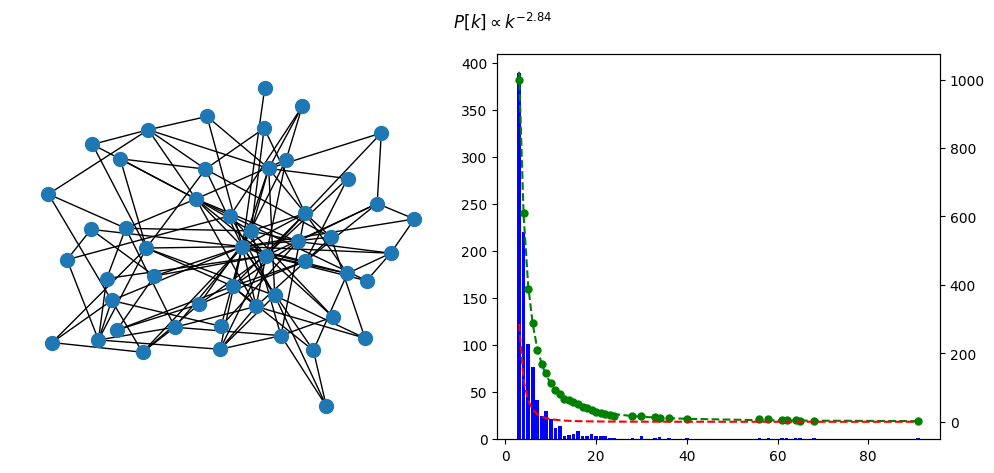

In [5]:
GRAPH_N0 = 5
HIST_N0 = 5
GRAPH_M = 3
HIST_M = 3
GRAPH_N = 50
HIST_N = 1000

visualise_params(
    GRAPH_N0,
    HIST_N0,
    GRAPH_M,
    HIST_M,
    GRAPH_N,
    HIST_N,
    [],
    [],
    lambda alpha, beta: lambda k: k,
    lambda alpha, beta: lambda k: 1,
    6,
    5,
    100,
    5,
)

### Non-Linear Preferential Attachment
* Sublinear Preferential Attachment: $\quad\quad k^\alpha \quad 0 \leq \alpha \leq 1$
* Superlinear Preferential Attachment: $\quad\quad k^\alpha \quad \alpha \geq 1$
* Log-Based Preferential Attachment: $\quad\quad \log(k + 1)^\alpha$

Sublinear preferential attachment:


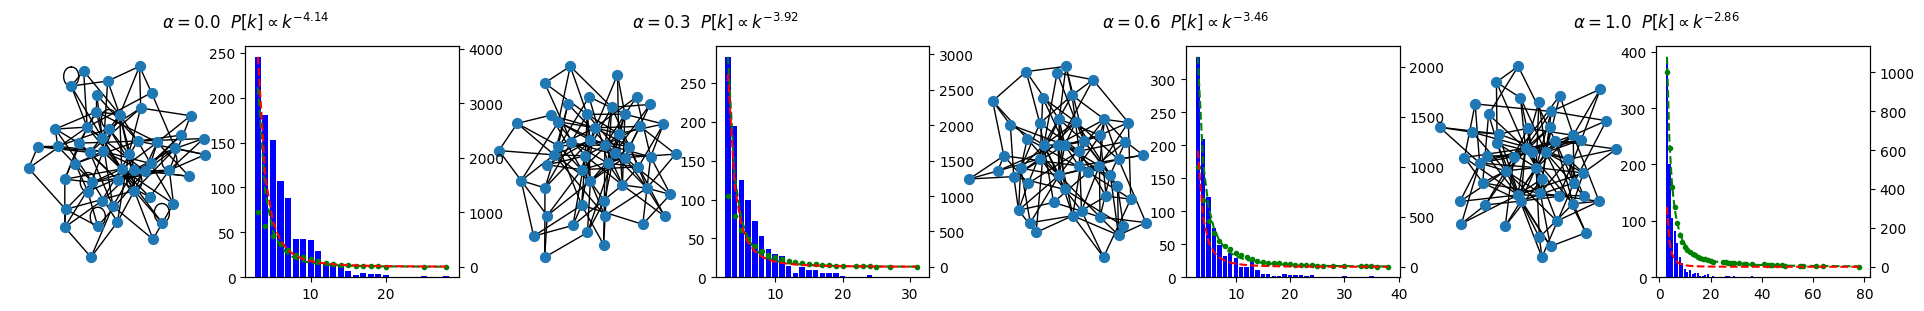

Superlinear preferential attachment:


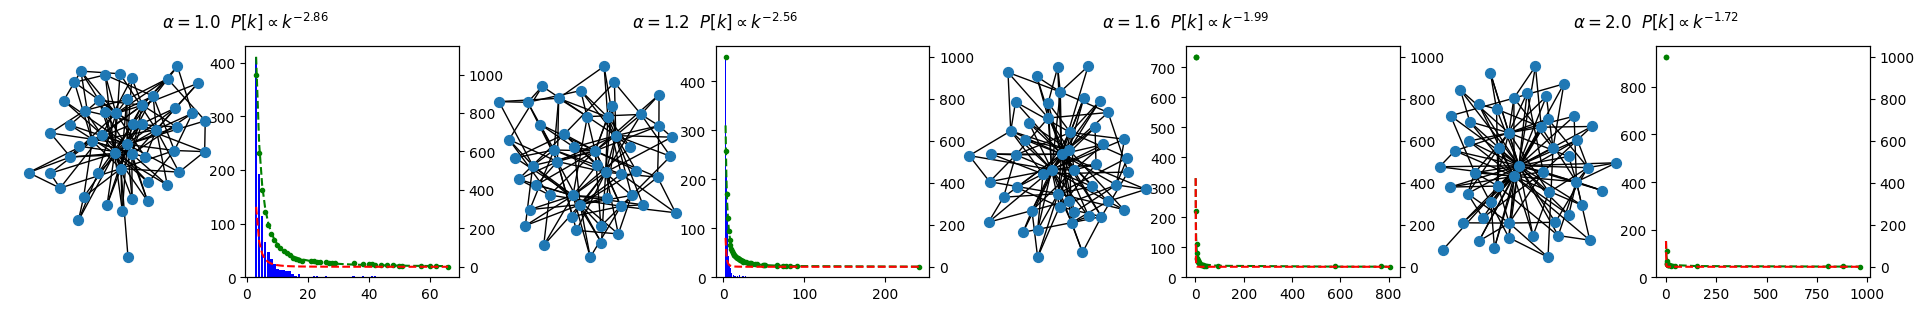

Log-Based preferential attachment:


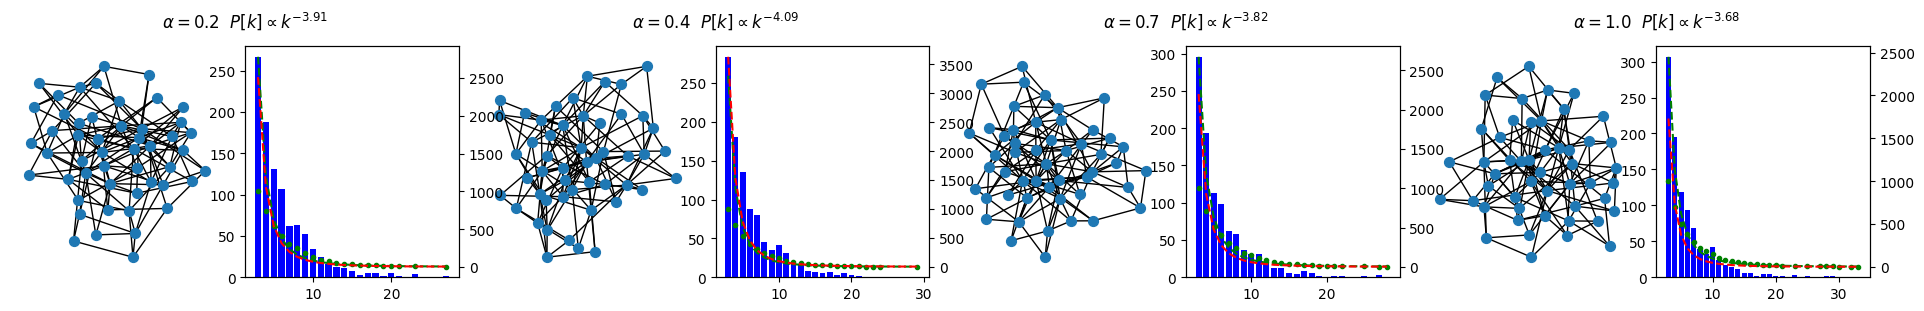

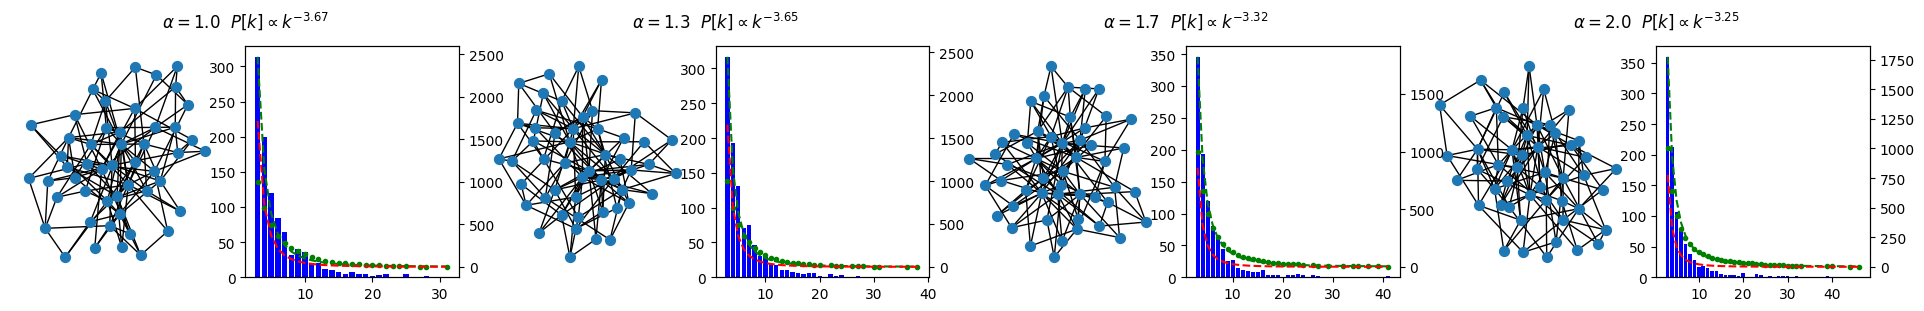

In [6]:
GRAPH_N0 = 5
HIST_N0 = 5
GRAPH_M = 3
HIST_M = 3
GRAPH_N = 50
HIST_N = 1000

print("Sublinear preferential attachment:")
visualise_params(
    GRAPH_N0,
    HIST_N0,
    GRAPH_M,
    HIST_M,
    GRAPH_N,
    HIST_N,
    [0.0, 0.3, 0.6, 1.0],
    [],
    lambda alpha, beta: lambda k: k**alpha,
    lambda alpha, beta: lambda k: 1,
    3,
    3,
    50,
    3,
)

print("Superlinear preferential attachment:")
visualise_params(
    GRAPH_N0,
    HIST_N0,
    GRAPH_M,
    HIST_M,
    GRAPH_N,
    HIST_N,
    [1.0, 1.2, 1.6, 2.0],
    [],
    lambda alpha, beta: lambda k: k**alpha,
    lambda alpha, beta: lambda k: 1,
    3,
    3,
    50,
    3,
)

print("Log-Based preferential attachment:")
visualise_params(
    GRAPH_N0,
    HIST_N0,
    GRAPH_M,
    HIST_M,
    GRAPH_N,
    HIST_N,
    [0.2, 0.4, 0.7, 1.0],
    [],
    lambda alpha, beta: lambda k: np.log(k + 1) ** alpha,
    lambda alpha, beta: lambda k: 1,
    3,
    3,
    50,
    3,
)
visualise_params(
    GRAPH_N0,
    HIST_N0,
    GRAPH_M,
    HIST_M,
    GRAPH_N,
    HIST_N,
    [1.0, 1.3, 1.7, 2.0],
    [],
    lambda alpha, beta: lambda k: np.log(k + 1) ** alpha,
    lambda alpha, beta: lambda k: 1,
    3,
    3,
    50,
    3,
)

### With Edge Creation Probability - Preferential Attachment / Log-Based Preferential Attachment

Constant edge creation probability:


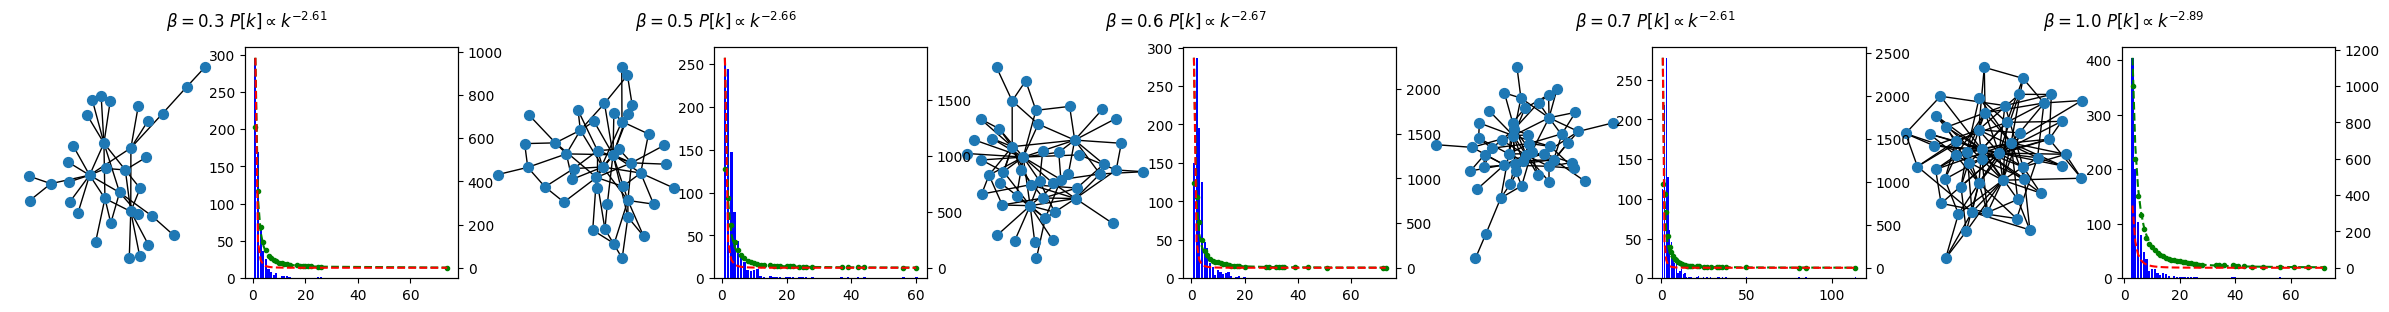

1/k edge creation probability:


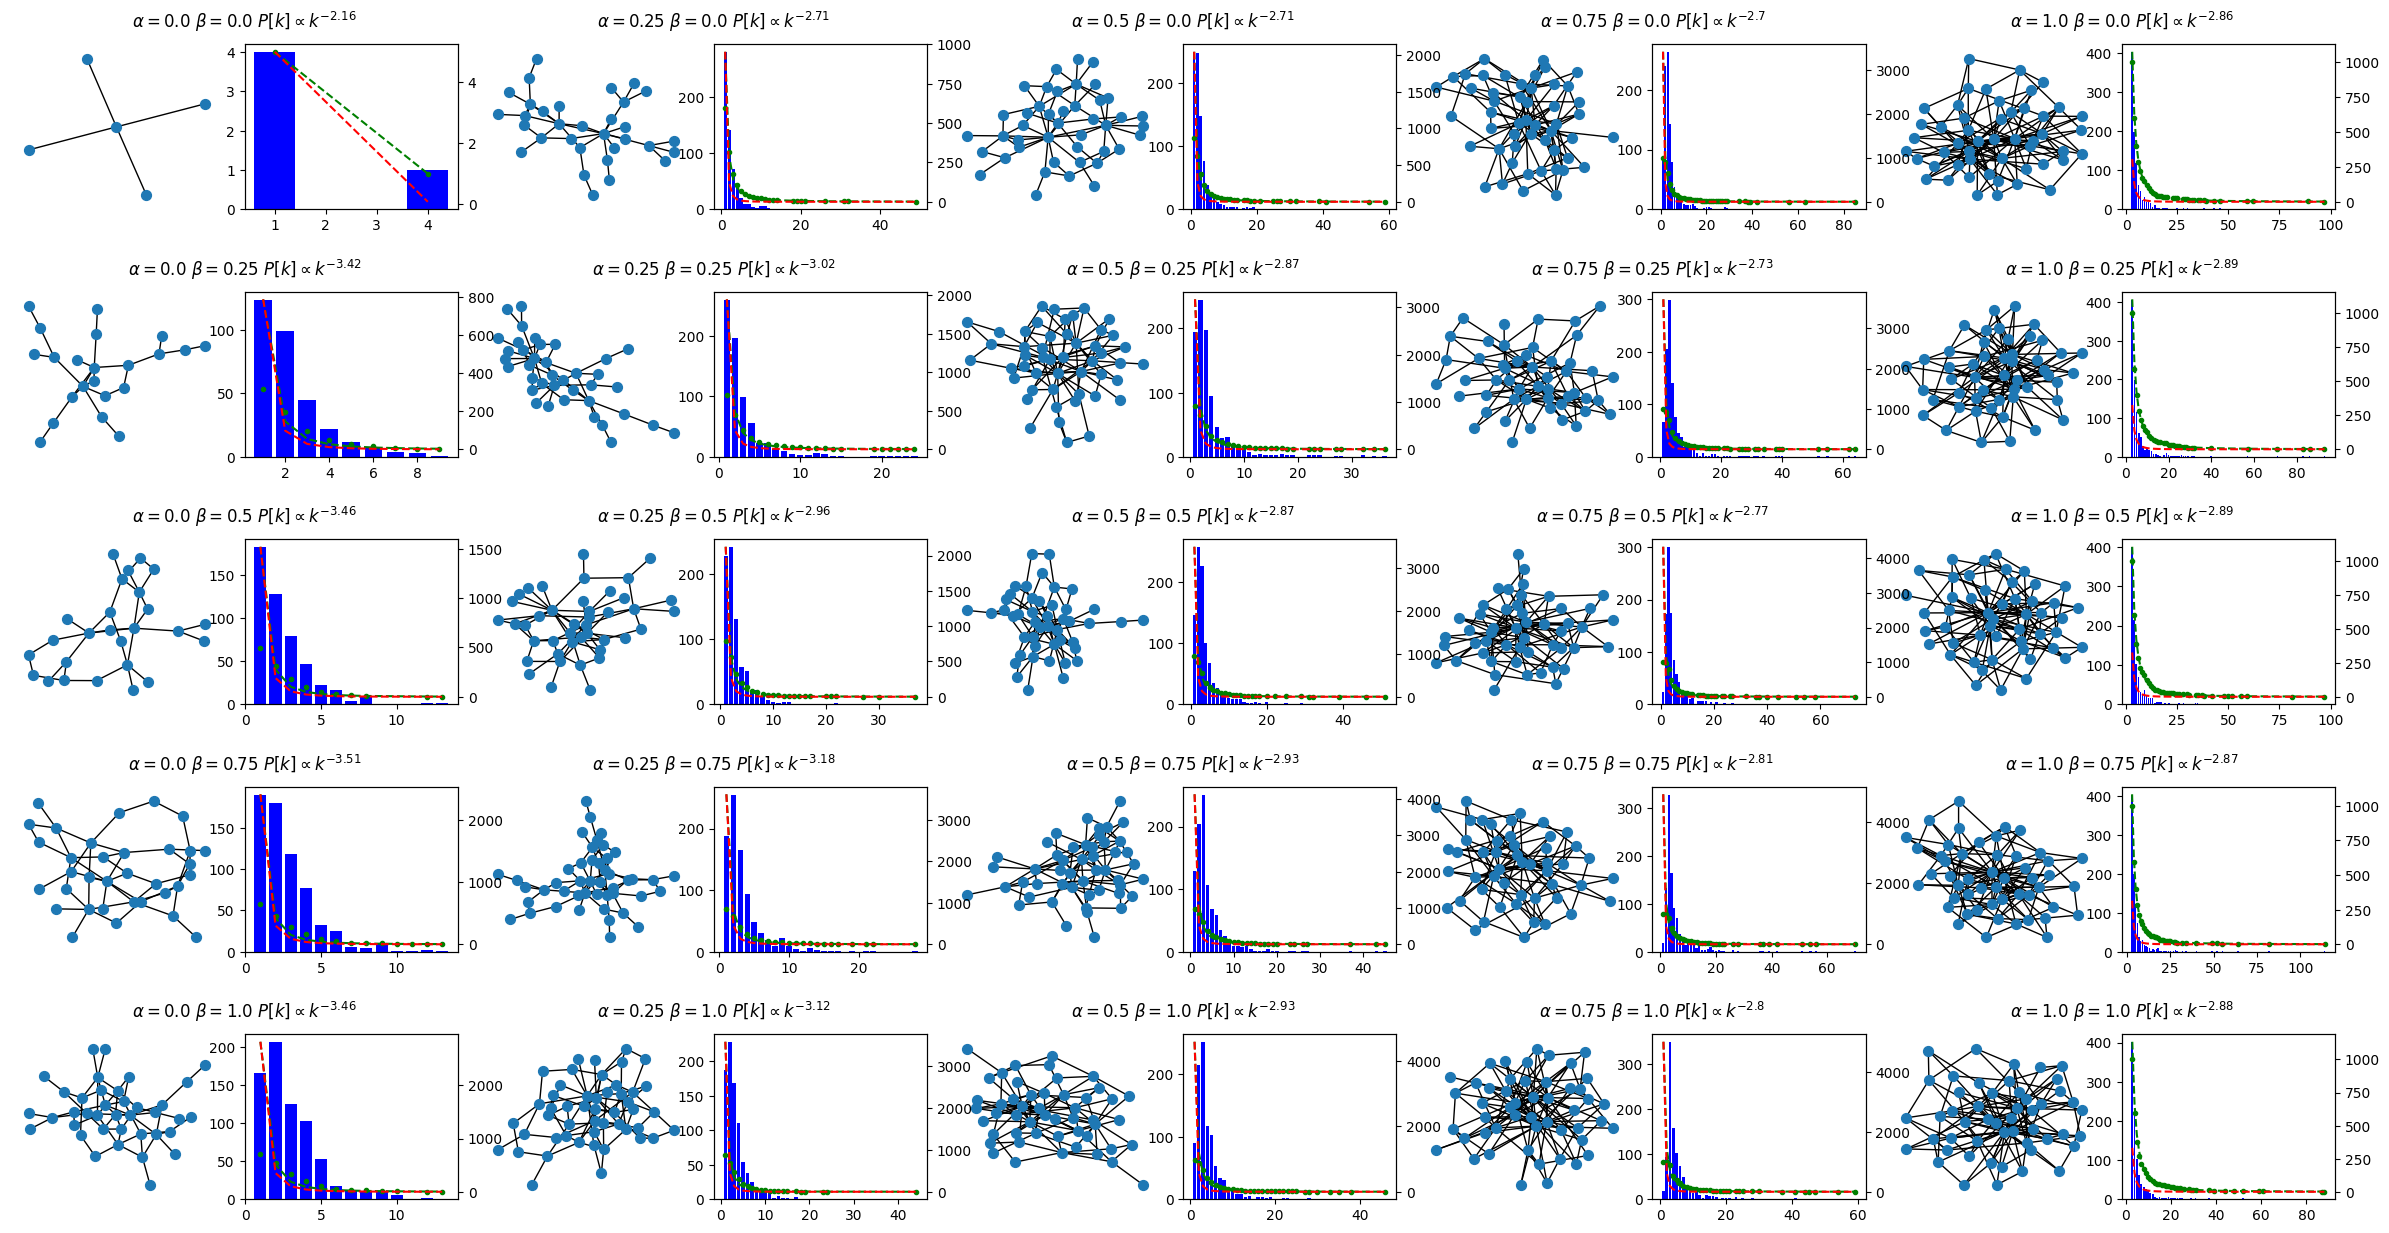

1/log(k+1) edge creation probability:


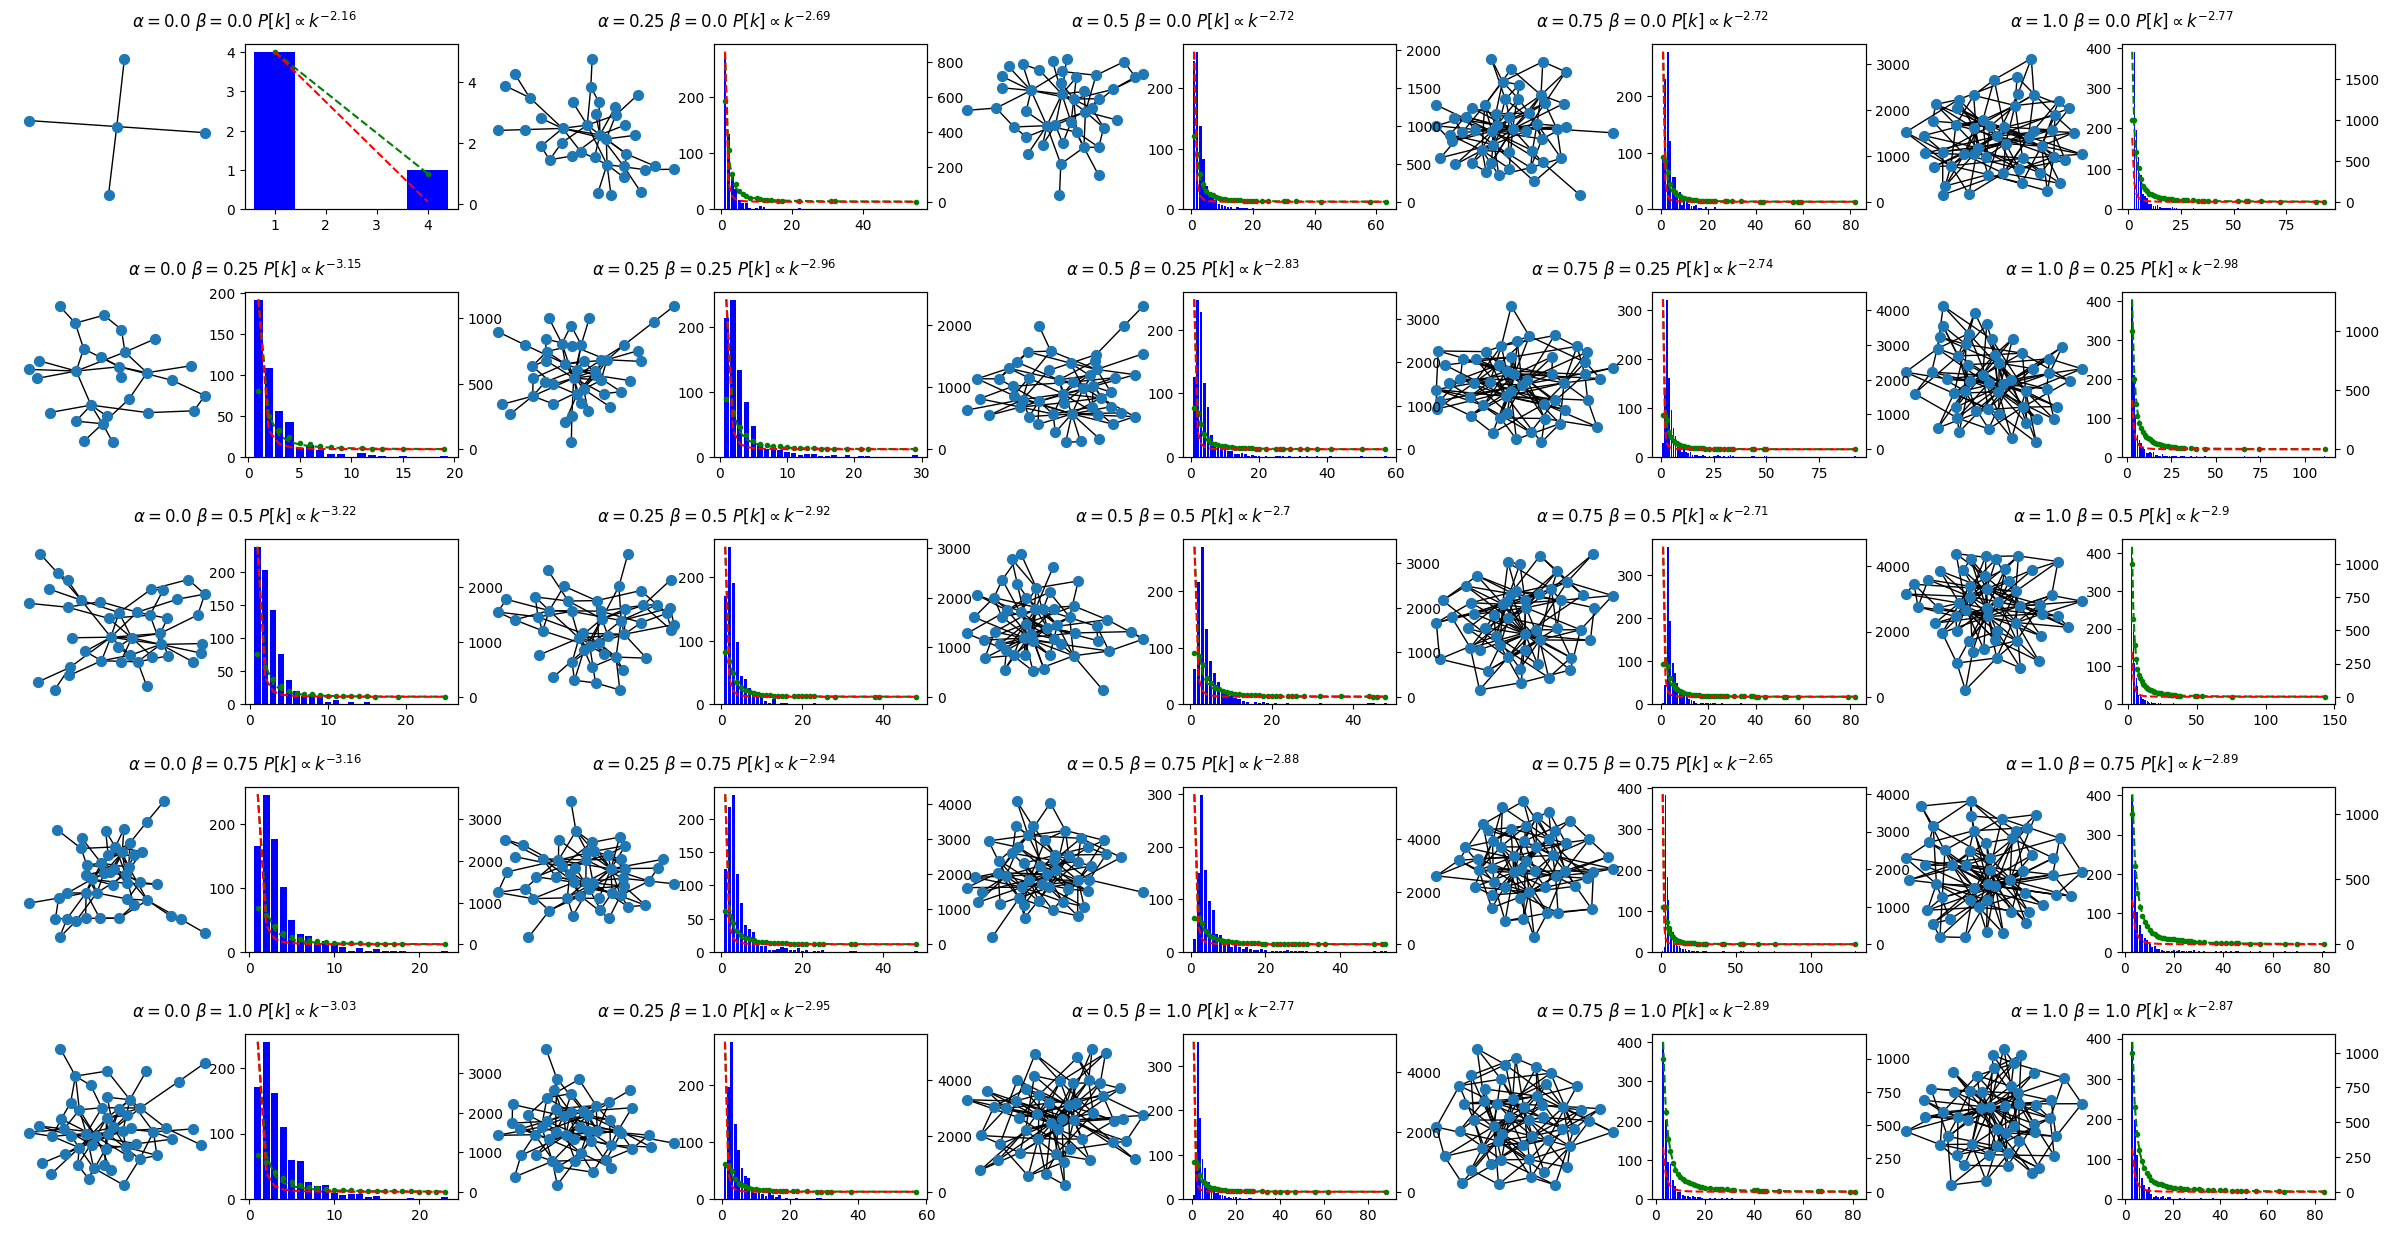

In [7]:
GRAPH_N0 = 5
HIST_N0 = 5
GRAPH_M = 3
HIST_M = 3
GRAPH_N = 50
HIST_N = 1000

print("Constant edge creation probability:")
visualise_params(
    GRAPH_N0,
    HIST_N0,
    GRAPH_M,
    HIST_M,
    GRAPH_N,
    HIST_N,
    [],
    [0.3, 0.5, 0.6, 0.7, 1.0],
    lambda alpha, beta: lambda k: k,
    lambda alpha, beta: lambda k: beta,
    # lambda alpha, beta: lambda k: math.log(k+1), lambda alpha, beta: lambda k: beta,
    3,
    3,
    50,
    3,
)

print("1/k edge creation probability:")
visualise_params(
    GRAPH_N0,
    HIST_N0,
    GRAPH_M,
    HIST_M,
    GRAPH_N,
    HIST_N,
    [0.0, 0.25, 0.5, 0.75, 1.0],
    [0.0, 0.25, 0.5, 0.75, 1.0],
    lambda alpha, beta: lambda k: k,
    lambda alpha, beta: lambda k: alpha + beta * (1 / k),
    # lambda alpha, beta: lambda k: math.log(k+1), lambda alpha, beta: lambda k: alpha + beta * (1 / k),
    3,
    3,
    50,
    3,
)

print("1/log(k+1) edge creation probability:")
visualise_params(
    GRAPH_N0,
    HIST_N0,
    GRAPH_M,
    HIST_M,
    GRAPH_N,
    HIST_N,
    [0.0, 0.25, 0.5, 0.75, 1.0],
    [0.0, 0.25, 0.5, 0.75, 1.0],
    lambda alpha, beta: lambda k: k,
    lambda alpha, beta: lambda k: alpha + beta * (1 / math.log(k + 1)),
    # lambda alpha, beta: lambda k: math.log(k+1), lambda alpha, beta: lambda k: alpha + beta * (1 / math.log(k + 1)),
    3,
    3,
    50,
    3,
)

### With Edge Creation Probability 2 - Preferential Attachment / Log-Based Preferential Attachment

Constant edge creation probability:


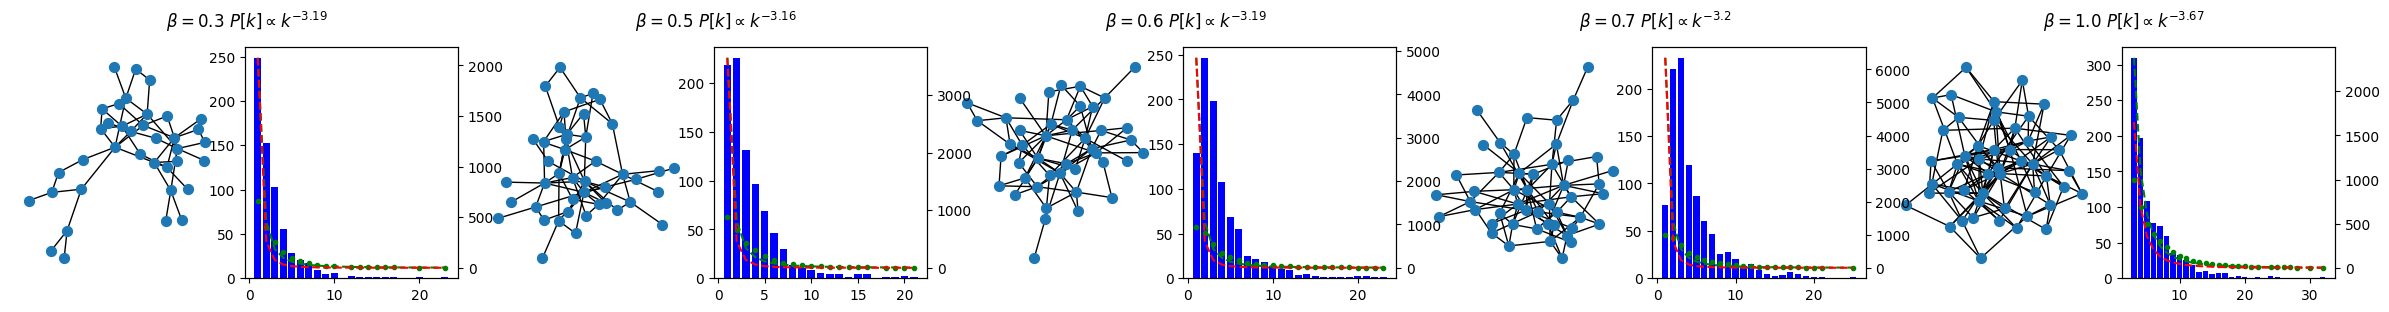

1/k edge creation probability:


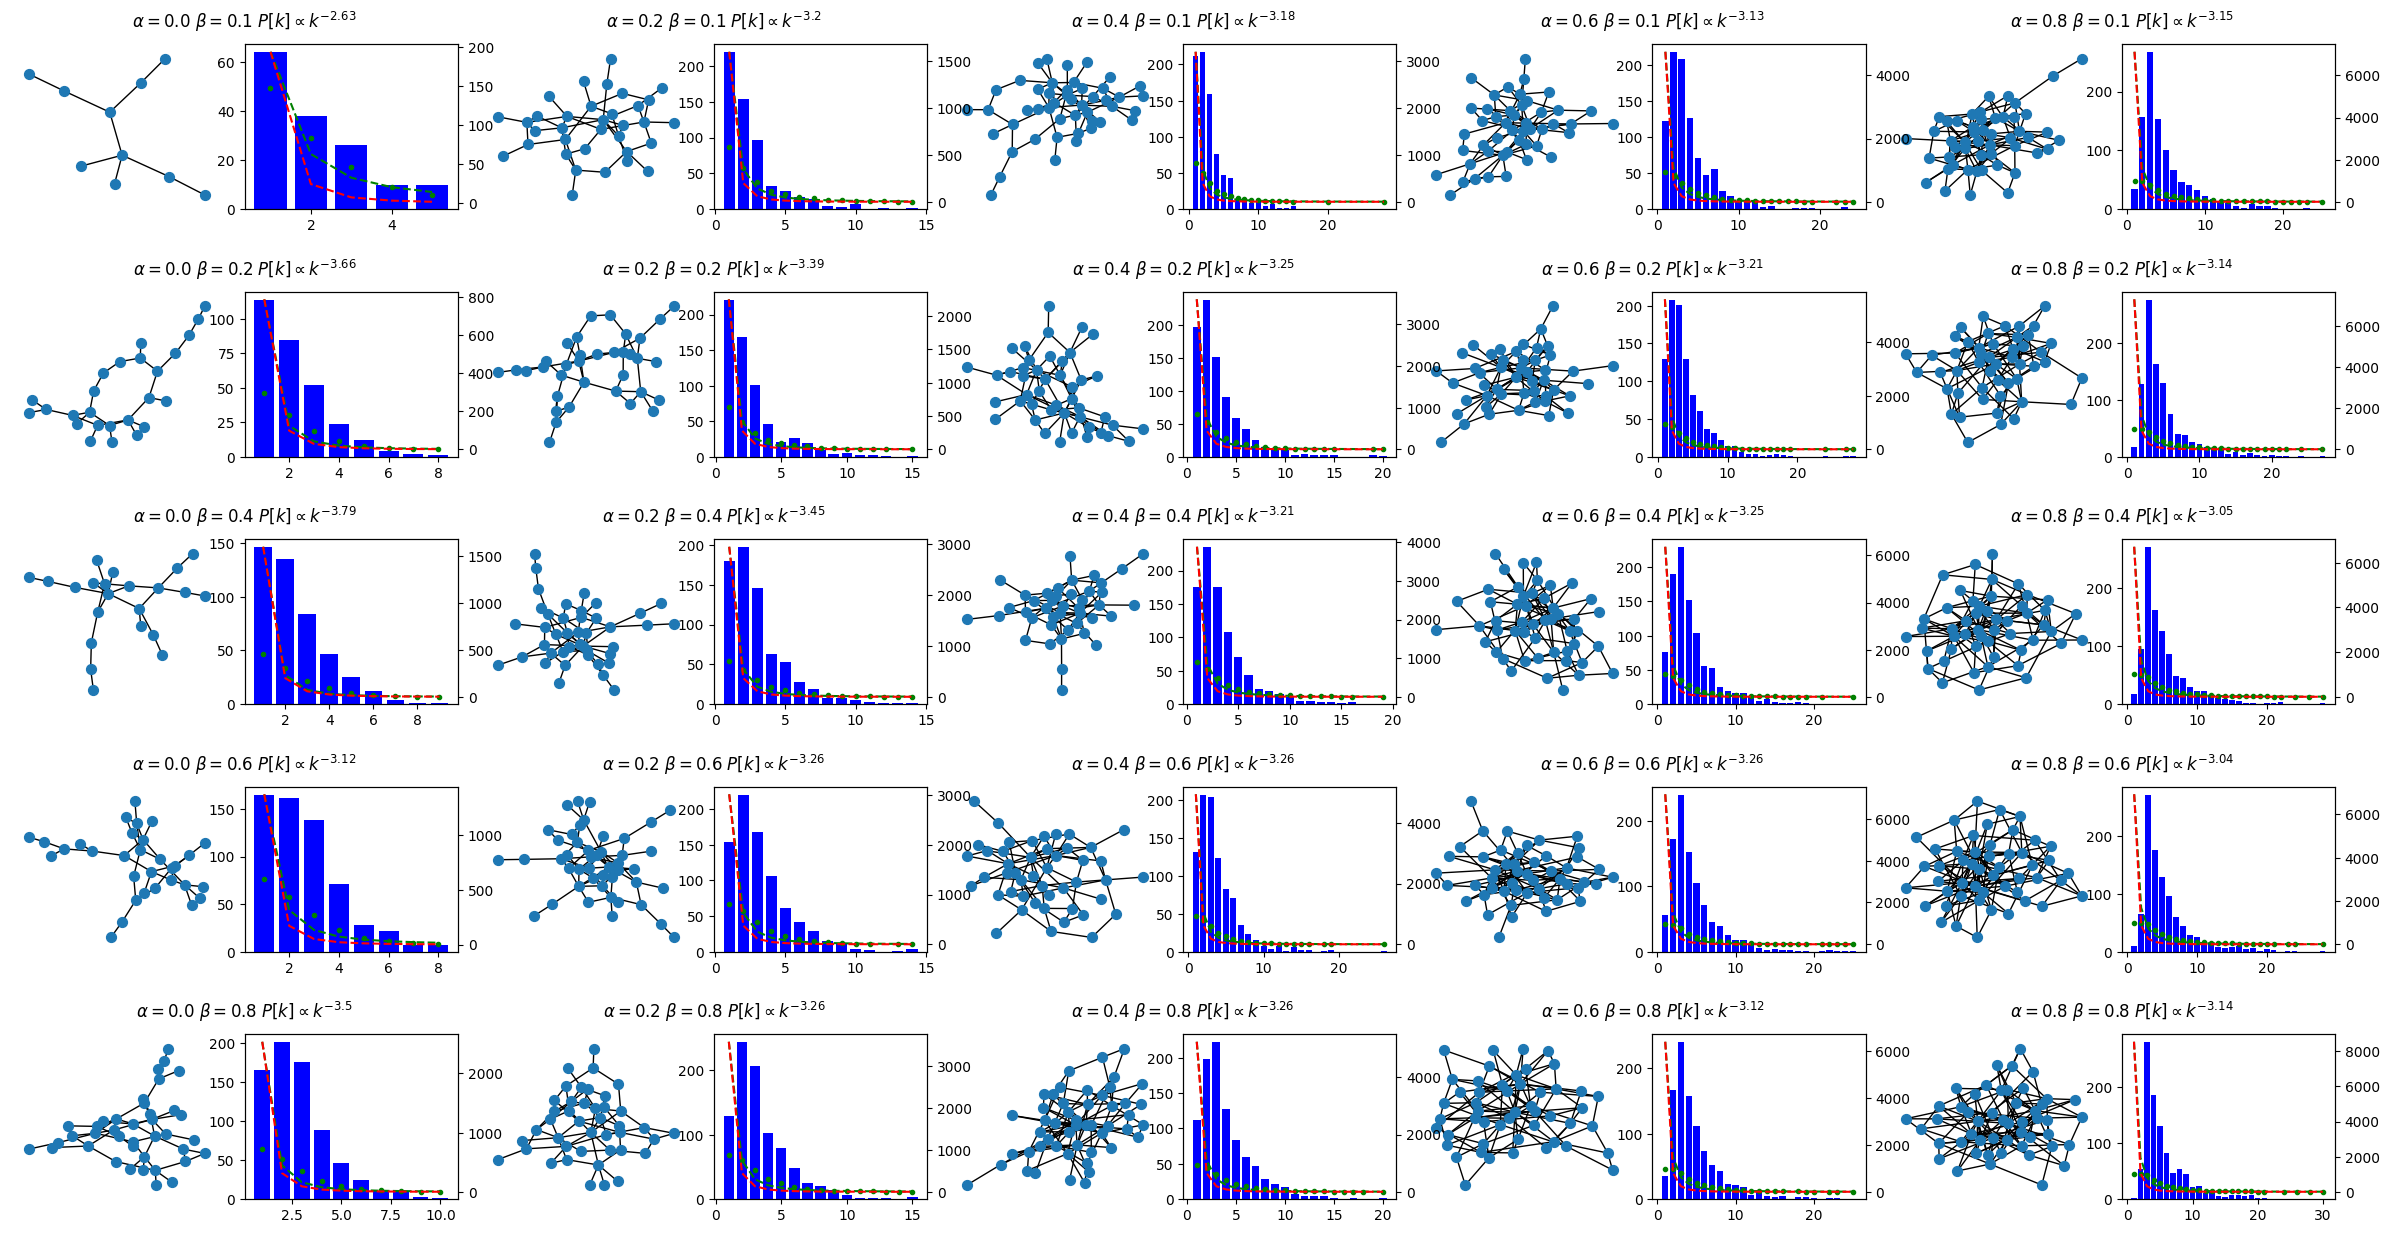

1/log(k+1) edge creation probability:


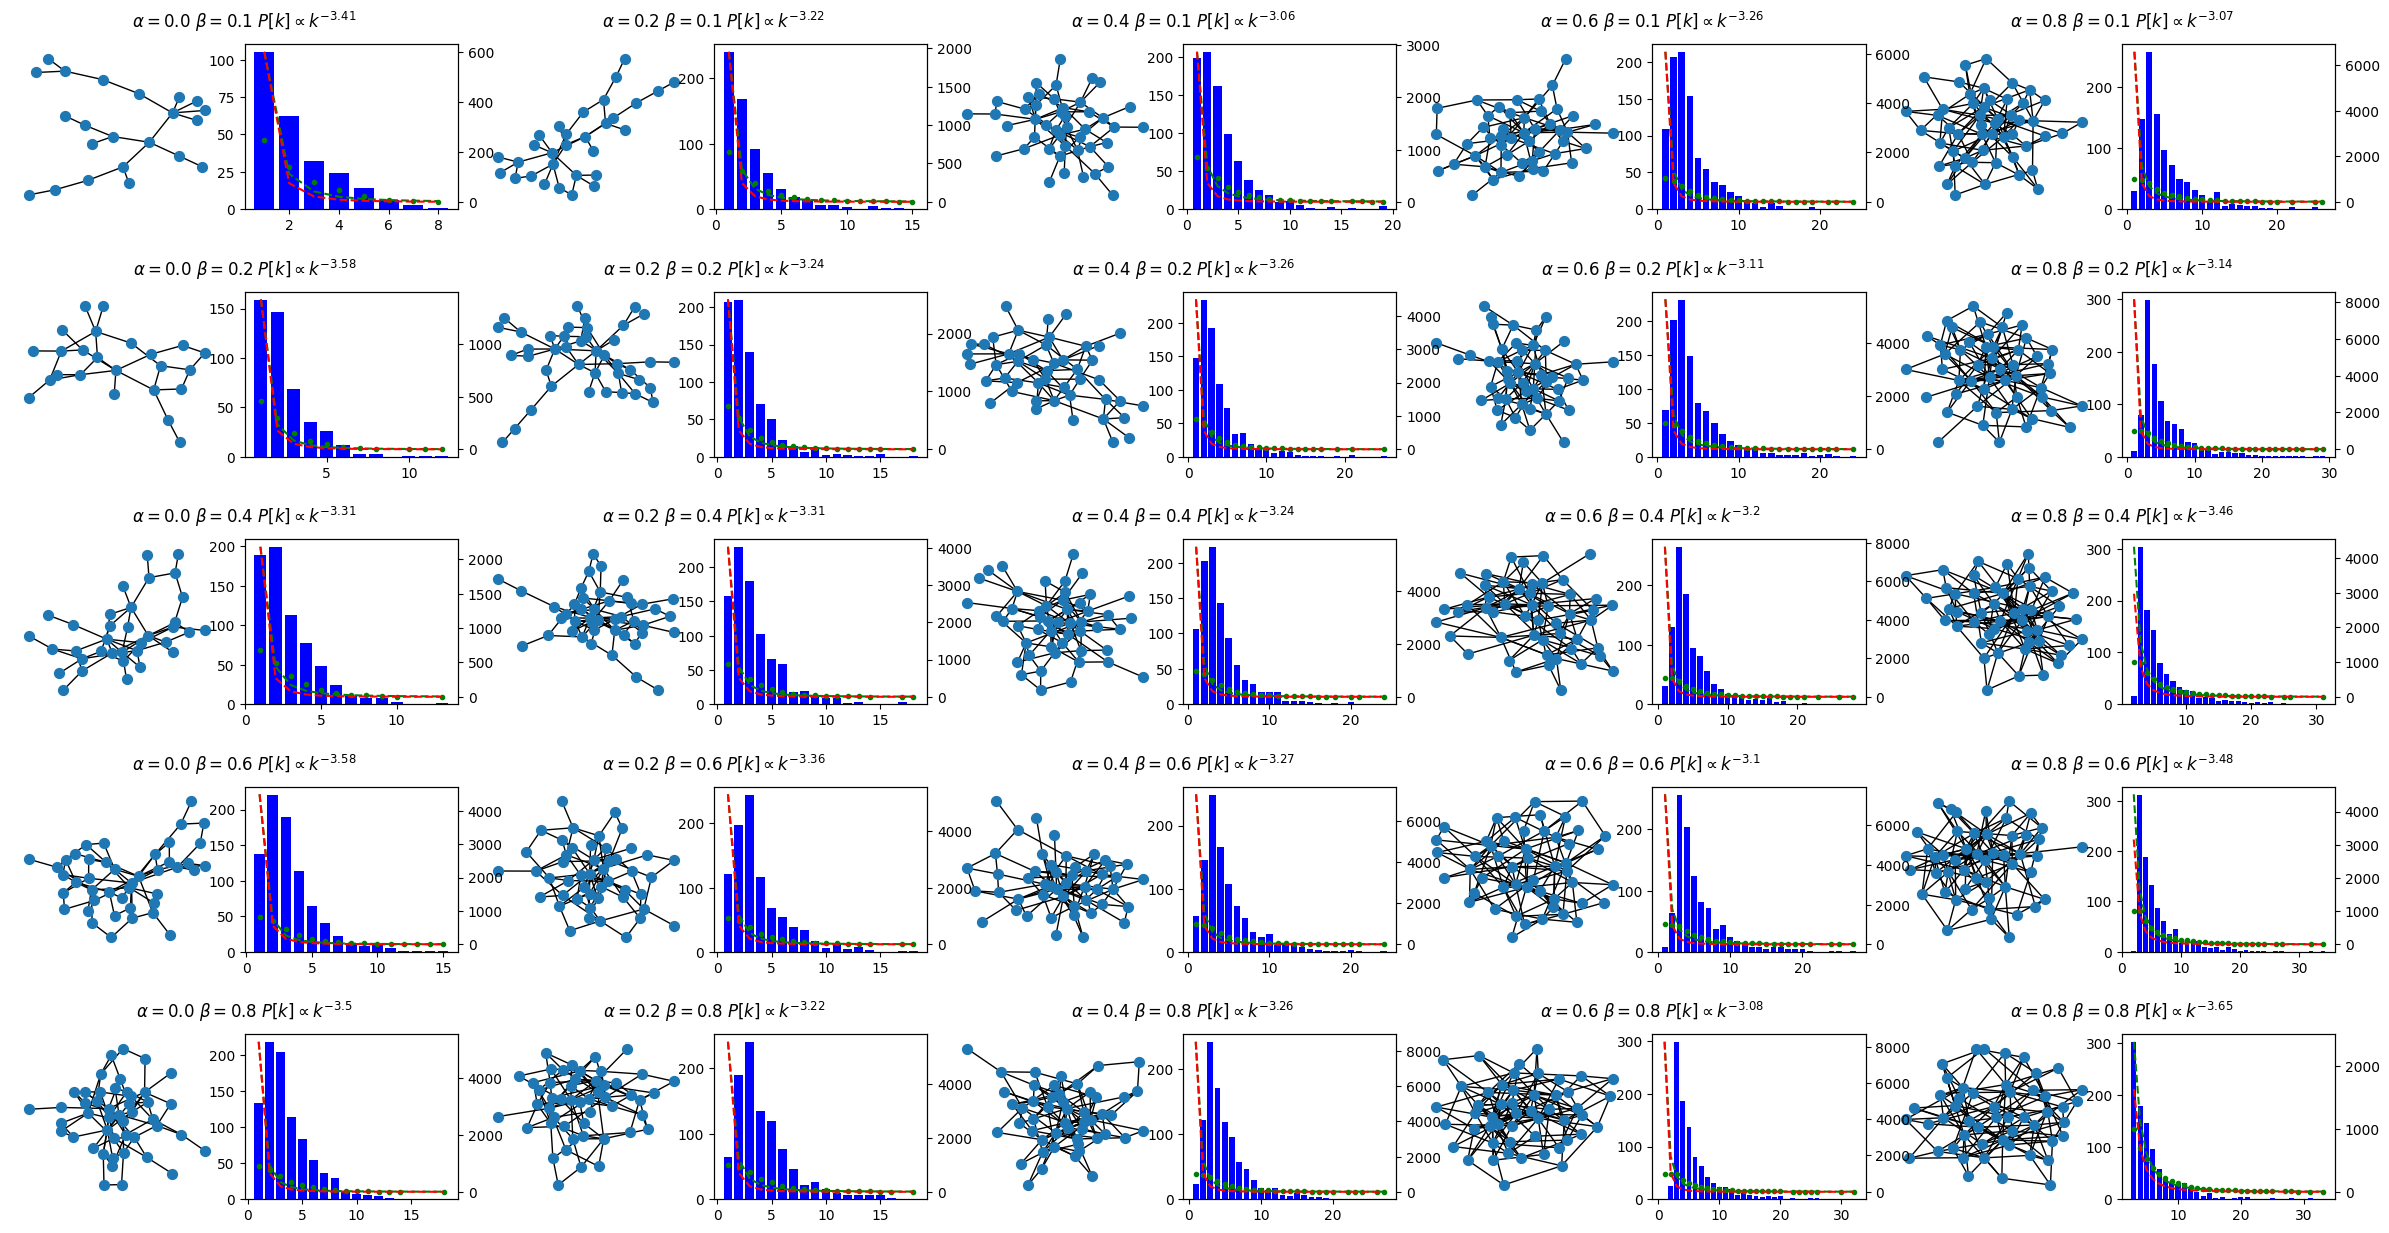

In [8]:
GRAPH_N0 = 5
HIST_N0 = 5
GRAPH_M = 3
HIST_M = 3
GRAPH_N = 50
HIST_N = 1000

print("Constant edge creation probability:")
visualise_params(
    GRAPH_N0,
    HIST_N0,
    GRAPH_M,
    HIST_M,
    GRAPH_N,
    HIST_N,
    [],
    [0.3, 0.5, 0.6, 0.7, 1.0],
    # lambda alpha, beta: lambda k: k, lambda alpha, beta: lambda k: beta,
    lambda alpha, beta: lambda k: math.log(k + 1),
    lambda alpha, beta: lambda k: beta,
    3,
    3,
    50,
    3,
)

print("1/k edge creation probability:")
visualise_params(
    GRAPH_N0,
    HIST_N0,
    GRAPH_M,
    HIST_M,
    GRAPH_N,
    HIST_N,
    [0.0, 0.2, 0.4, 0.6, 0.8],
    [0.1, 0.2, 0.4, 0.6, 0.8],
    # lambda alpha, beta: lambda k: k, lambda alpha, beta: lambda k: alpha + beta * (1 - (1 / k)),
    lambda alpha, beta: lambda k: math.log(k + 1),
    lambda alpha, beta: lambda k: alpha + beta * (1 / k),
    3,
    3,
    50,
    3,
)

print("1/log(k+1) edge creation probability:")
visualise_params(
    GRAPH_N0,
    HIST_N0,
    GRAPH_M,
    HIST_M,
    GRAPH_N,
    HIST_N,
    [0.0, 0.2, 0.4, 0.6, 0.8],
    [0.1, 0.2, 0.4, 0.6, 0.8],
    # lambda alpha, beta: lambda k: k, lambda alpha, beta: lambda k: alpha + beta * (1 - (1 / math.log(k + 1))),
    lambda alpha, beta: lambda k: math.log(k + 1),
    lambda alpha, beta: lambda k: alpha + beta * (1 / math.log(k + 1)),
    3,
    3,
    50,
    3,
)

In [9]:
def analyse_graph(G: nx.Graph) -> None:
    degs_list = sorted([degree for _, degree in G.degree])
    degs = sorted(list(set(degs_list)))
    counts = [degs_list.count(deg) for deg in degs]

    cdf = np.cumsum(counts[::-1])[::-1]
    log_deg = np.log(degs)
    log_cdf = np.log(cdf)

    slope, intercept, r_value, p_value, std_err = stats.linregress(log_deg, log_cdf)
    reg_line = slope * log_deg + intercept

    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.bar(
        degs, counts, width=0.8, color="skyblue", edgecolor="black", label="Histogram"
    )
    ax1.set_xlabel("x value")
    ax1.set_ylabel("Counts", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")
    ax1.set_title(f"Histogram + log-log CDF + Linear Fit ({sum(counts)} nodes)")

    ax2 = ax1.twinx()
    ax2.plot(degs, np.exp(log_cdf), "o", color="darkred", label="CDF >= k")
    ax2.plot(degs, np.exp(reg_line), "--", color="red", label=f"Fit: slope={slope:.2f}")
    ax2.set_ylabel("CDF (>= k)", color="darkred")
    ax2.set_yscale("log")
    ax2.set_xscale("log")
    ax2.tick_params(axis="y", labelcolor="darkred")

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

    plt.tight_layout()
    plt.show()

Preferential attachment with constant edge creation probability:


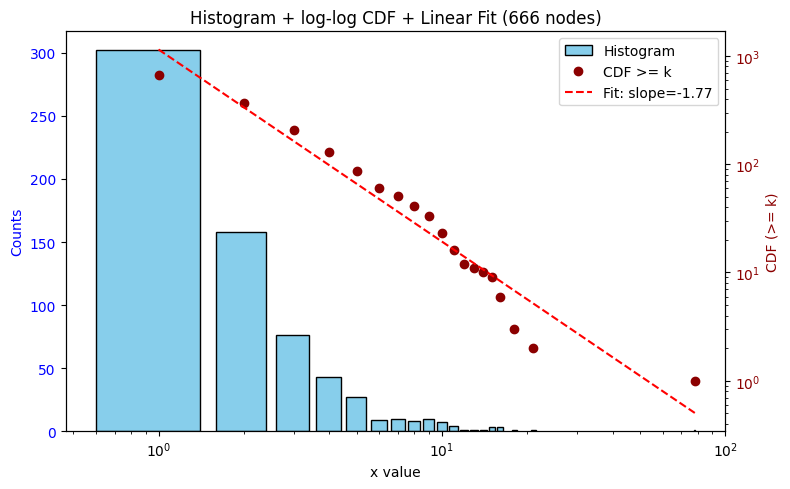

Preferential attachment with 1/k edge creation probability:


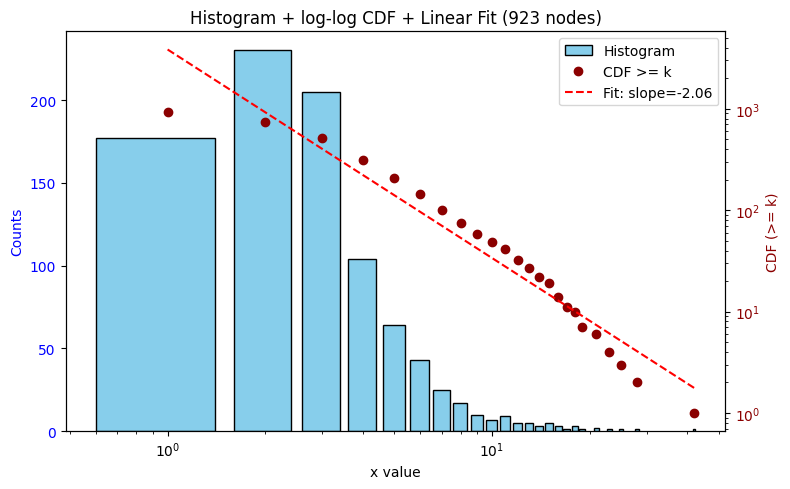

Preferential attachment with 1/log(k+1) edge creation probability:


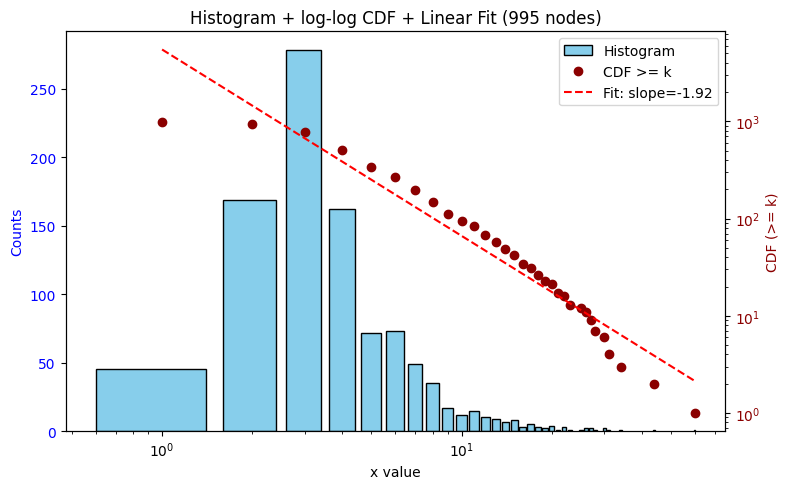

Preferential attachment with 1 - 1/k edge creation probability:


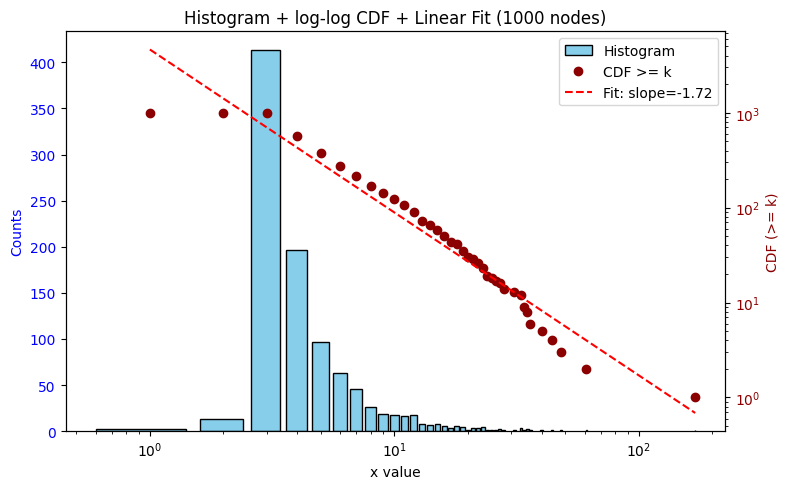

Preferential attachment with 1 - 1/log(k+1) edge creation probability:


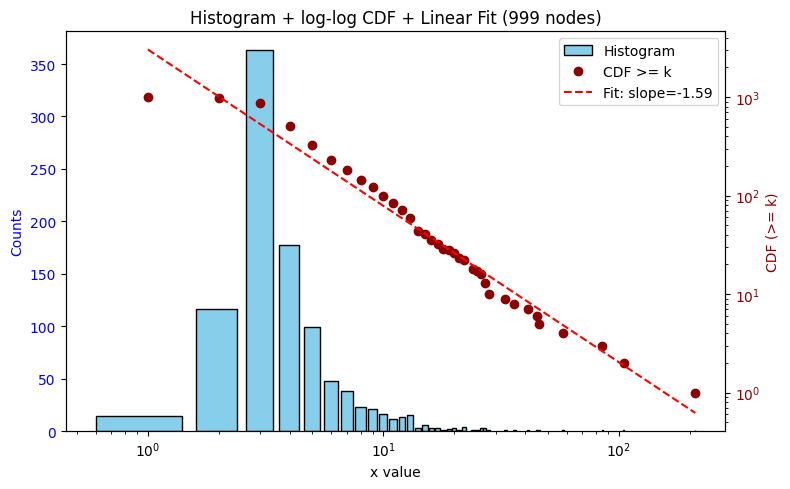

In [10]:
N0 = 10
M = 3
N = 1000

print("Preferential attachment with constant edge creation probability:")
G1 = generate_graph(N0, N, M, lambda k: k, lambda k: 0.3)
analyse_graph(G1)

print("Preferential attachment with 1/k edge creation probability:")
G2 = generate_graph(N0, N, M, lambda k: k, lambda k: 0.3 + 1 / k)
analyse_graph(G2)

print("Preferential attachment with 1/log(k+1) edge creation probability:")
G3 = generate_graph(N0, N, M, lambda k: k, lambda k: 0.3 + 1 / math.log(k + 1))
analyse_graph(G3)

print("Preferential attachment with 1 - 1/k edge creation probability:")
G4 = generate_graph(N0, N, M, lambda k: k, lambda k: 0.3 + 1 - (1 / k))
analyse_graph(G4)

print("Preferential attachment with 1 - 1/log(k+1) edge creation probability:")
G5 = generate_graph(
    N0, N, M, lambda k: k, lambda k: 0.6 + 0.8 * (1 - (1 / math.log(k + 1)))
)
analyse_graph(G5)

In [11]:
N0 = 10
M = 3
N = 1000

G = generate_graph(N0, N, M, lambda k: math.log(k+1), lambda k: 1)
# G = generate_graph(N0, N, M, lambda k: k**0.05, lambda k: 1)

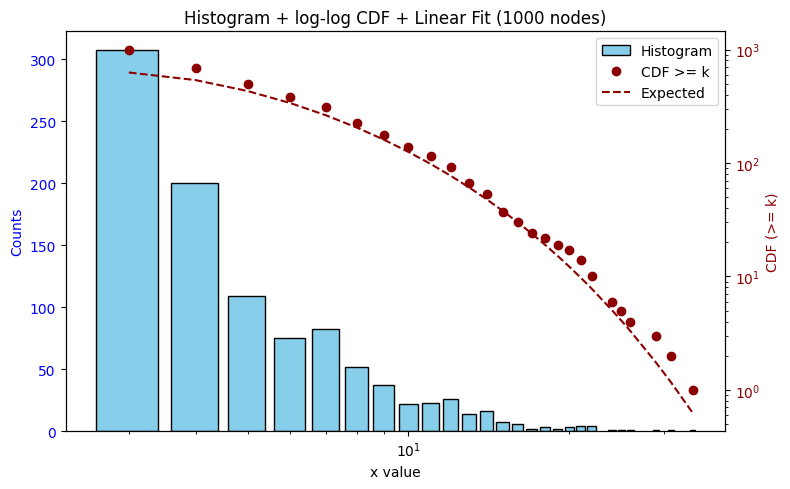

In [12]:
def analyse_graph2(G: nx.Graph) -> None:
    degs_list = sorted([degree for _, degree in G.degree])
    degs = sorted(list(set(degs_list)))
    counts = [degs_list.count(deg) for deg in degs]

    cdf = np.cumsum(counts[::-1])[::-1]
    log_deg = np.log(degs)
    log_cdf = np.log(cdf)

    expected = [math.exp(-deg / math.log(deg)) for deg in degs]
    # expected = [1 / math.log(deg) * math.exp(-deg / math.log(deg)) for deg in degs]
    scale = cdf[len(degs) // 2] / expected[len(degs) // 2]
    expected_scaled = [scale * val for val in expected]

    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.bar(
        degs, counts, width=0.8, color="skyblue", edgecolor="black", label="Histogram"
    )
    ax1.set_xlabel("x value")
    ax1.set_ylabel("Counts", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")
    ax1.set_title(f"Histogram + log-log CDF + Linear Fit ({sum(counts)} nodes)")

    ax2 = ax1.twinx()
    ax2.plot(degs, np.exp(log_cdf), "o", color="darkred", label="CDF >= k")
    ax2.plot(degs, expected_scaled, "--", color="darkred", label="Expected")
    ax2.set_ylabel("CDF (>= k)", color="darkred")
    ax2.set_yscale("log")
    ax2.set_xscale("log")
    ax2.tick_params(axis="y", labelcolor="darkred")

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

    plt.tight_layout()
    plt.show()

analyse_graph2(G)

In [ ]:
N_VALUES = [50, 100, 200, 400, 600, 800, 1000]
M_VALUES = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
P_VALUES = [0.1, 0.3, 0.5, 0.7, 0.8, 0.9]
REPS = 10

def experiment(n0: int, n: int, m: int, p: float) -> float:
    G = generate_graph(n0, n, m, lambda k: k, lambda k: p)
    degs_list = sorted([degree for _, degree in G.degree])
    degs = sorted(list(set(degs_list)))
    counts = [degs_list.count(deg) for deg in degs]

    return {deg: count for deg, count in zip(degs, counts) if deg > 0}


results_sum = {}
results_count = {}
results = {}
for n in N_VALUES:
    for m in M_VALUES:
        print(f"Running experiment for n={n}, m={m}")
        for p in P_VALUES:
            n_div_p = round(n / p)
            key = (n_div_p, m, p)
            results_sum[key] = {}
            results_count[key] = {}
            for _ in range(REPS):
                deg_count = experiment(15, n_div_p, m, p)
                for deg, count in deg_count.items():
                    if deg not in results_sum[key]:
                        results_sum[key][deg] = 0
                        results_count[key][deg] = 0
                    results_sum[key][deg] += count
                    results_count[key][deg] += 1

            for deg in results_sum[key]:
                results_sum[key][deg] /= results_count[key][deg]

            results[key] = dict(sorted(results_sum[key].items()))
   
with open("experiment_results.txt", 'wb') as f:
    import pickle
    pickle.dump(results, f)

In [14]:
with open("experiment_results.txt", 'rb') as f:
    import pickle
    results = pickle.load(f)

max_count_deg = {}
for n in N_VALUES:
    for m in M_VALUES:
        for p in P_VALUES:
            n_div_p = round(n / p)
            key = (n_div_p, m, p)
            degs = list(results[key].keys())
            counts = list(results[key].values())
            
            max_count = max(counts)
            max_deg = degs[counts.index(max_count)]
            max_count_deg[(n_div_p, m, p)] = (max_deg, max_count)

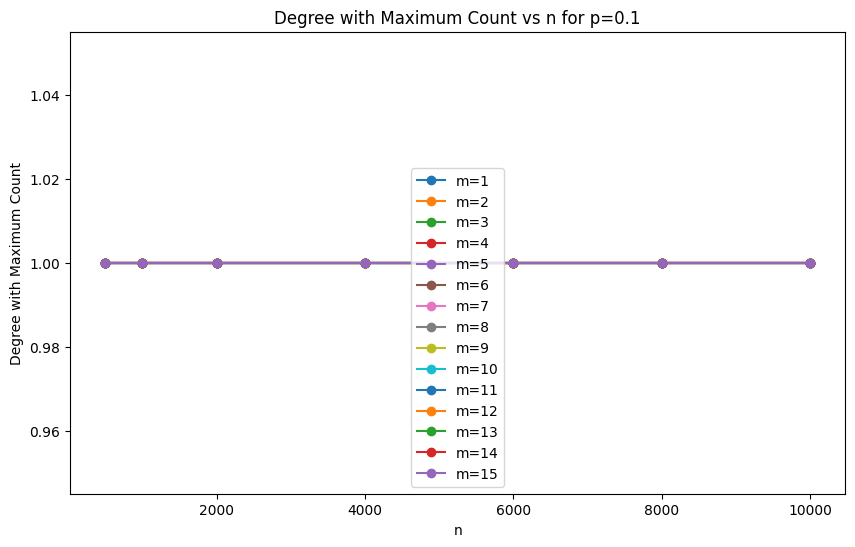

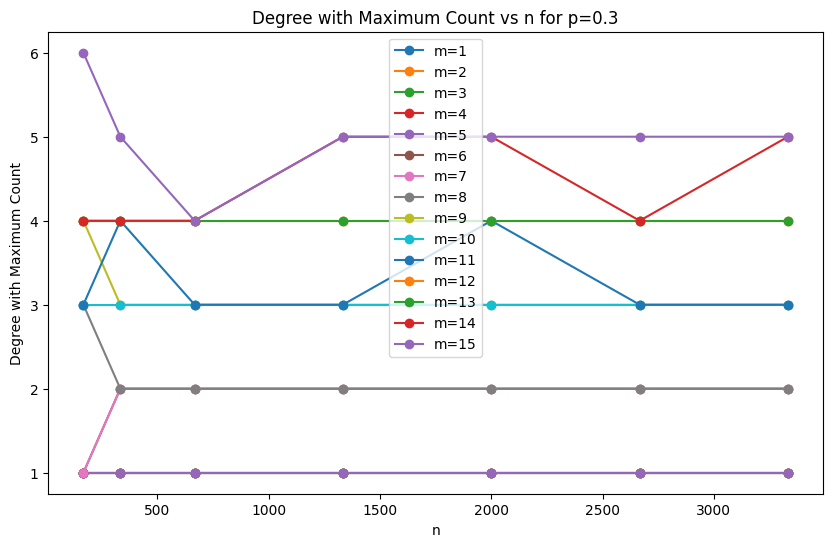

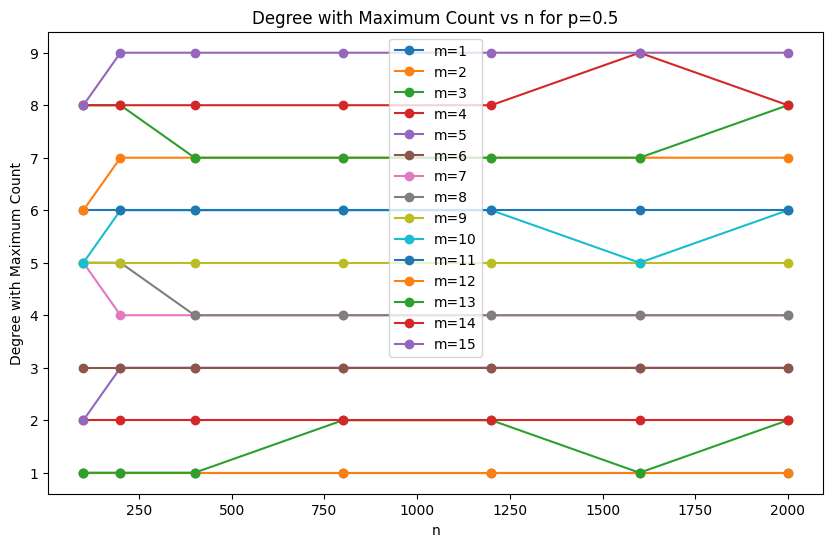

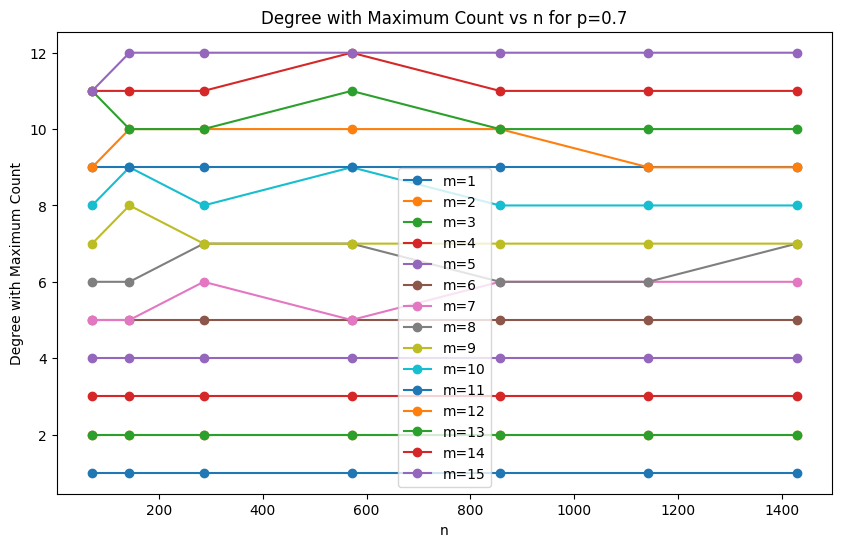

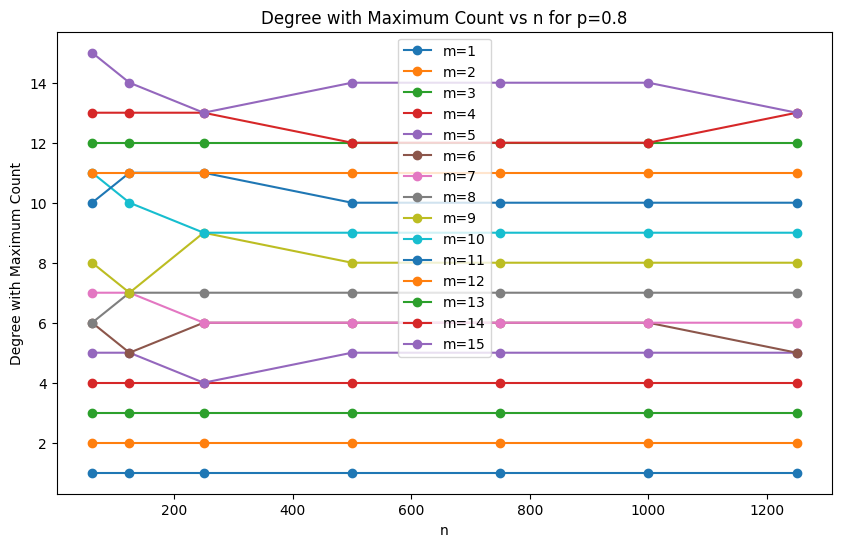

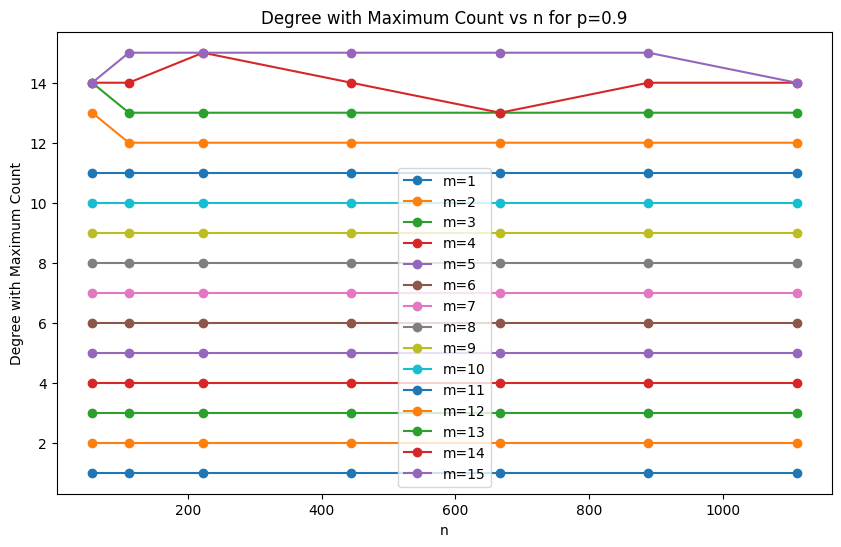

In [15]:
for p in P_VALUES:
    plt.figure(figsize=(10, 6))
    for m in M_VALUES:
        x = []
        y = []
        for n in N_VALUES:
            n_div_p = round(n / p)
            key = (n_div_p, m, p)
            if key in max_count_deg:
                max_deg, max_count = max_count_deg[key]
                x.append(n_div_p)
                y.append(max_deg)

        plt.plot(x, y, marker='o', label=f'm={m}')
        
    plt.title(f'Degree with Maximum Count vs n for p={p}')
    plt.xlabel('n')
    plt.ylabel('Degree with Maximum Count')
    plt.legend()
    plt.show()

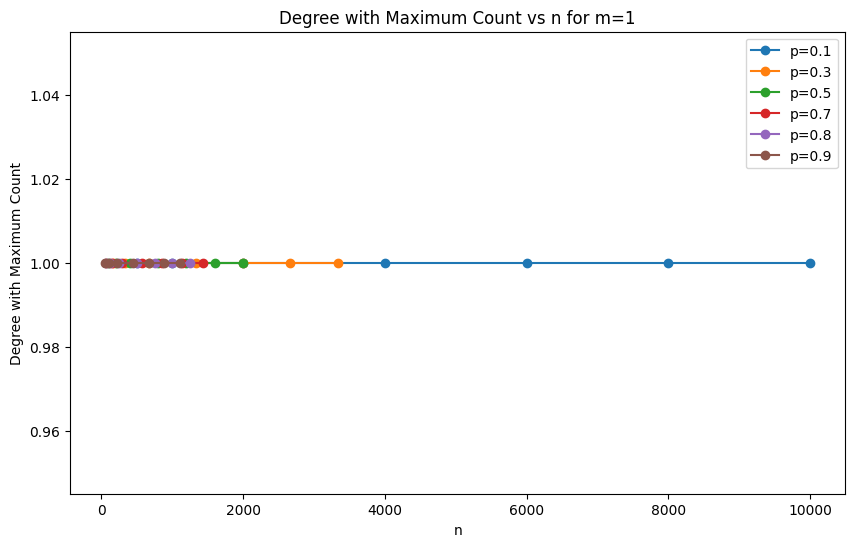

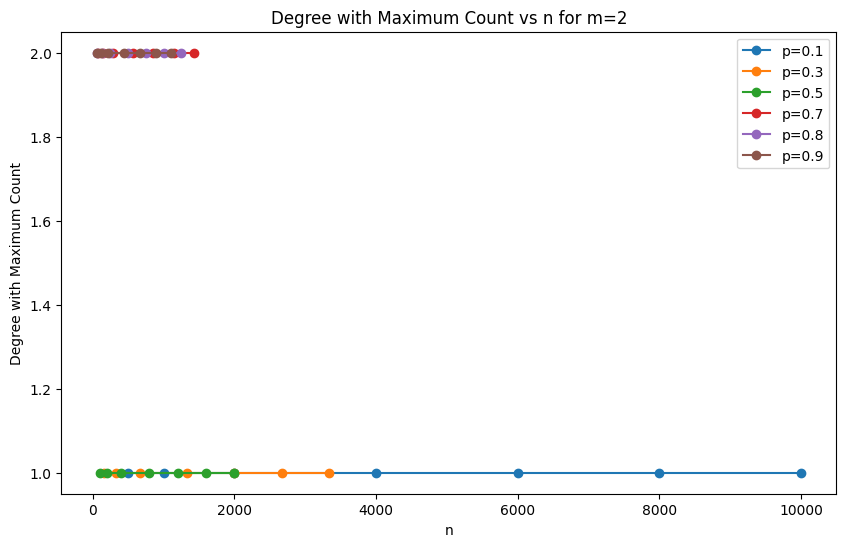

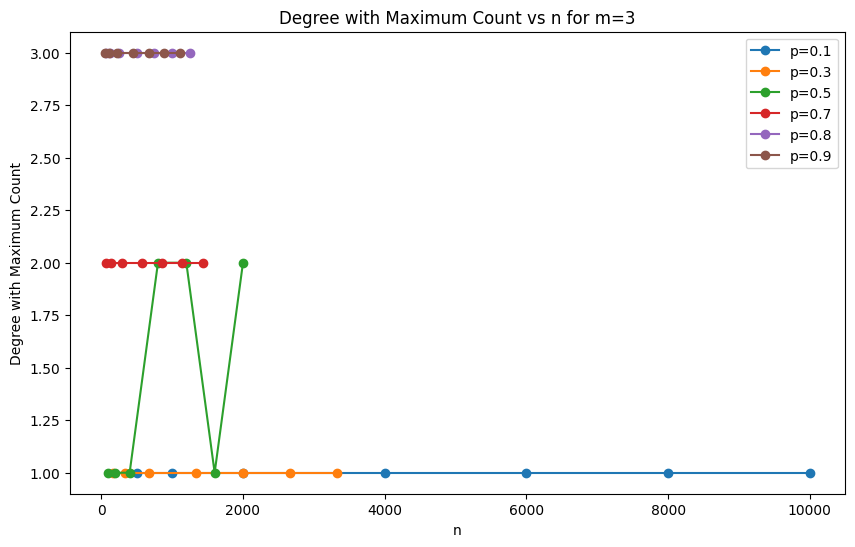

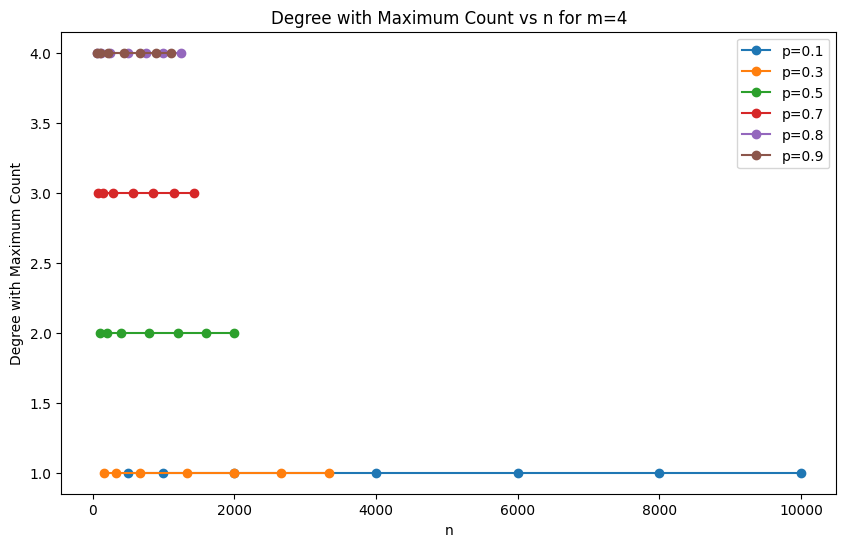

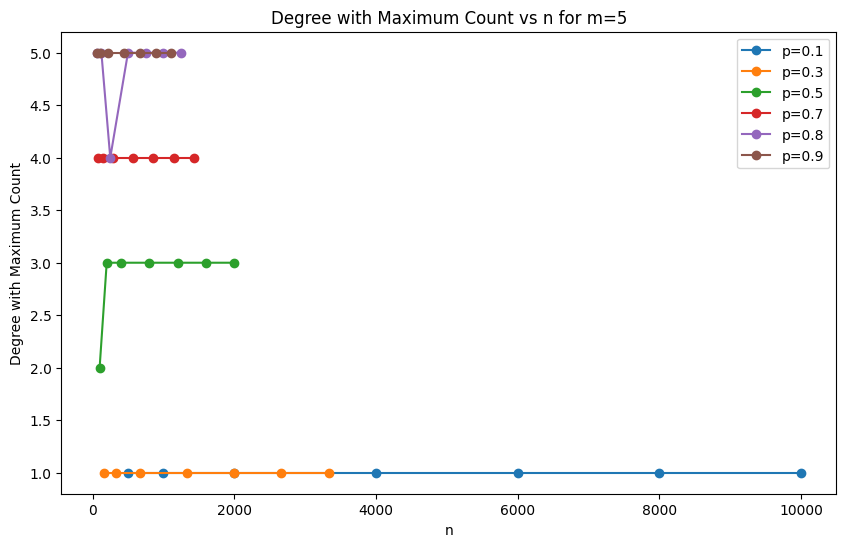

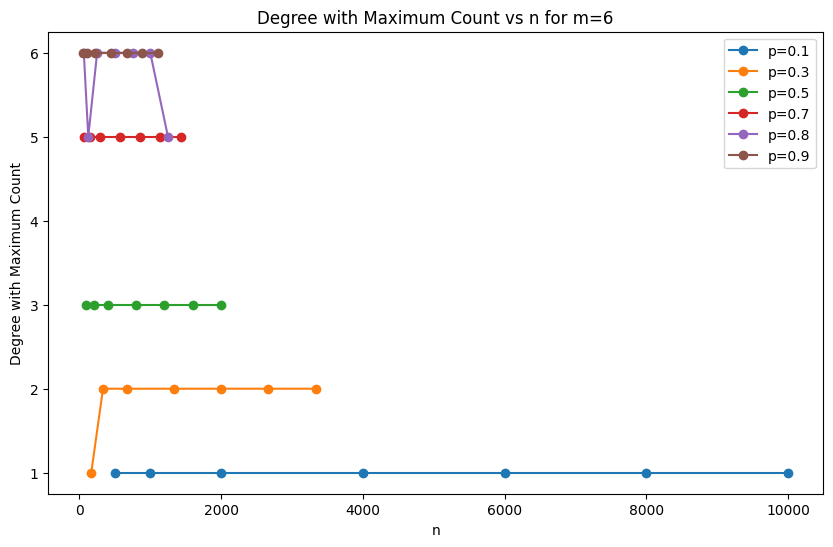

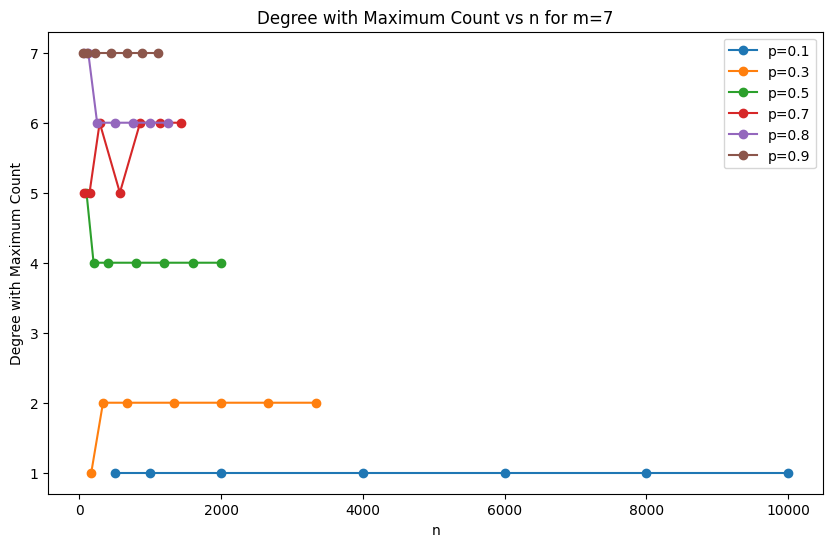

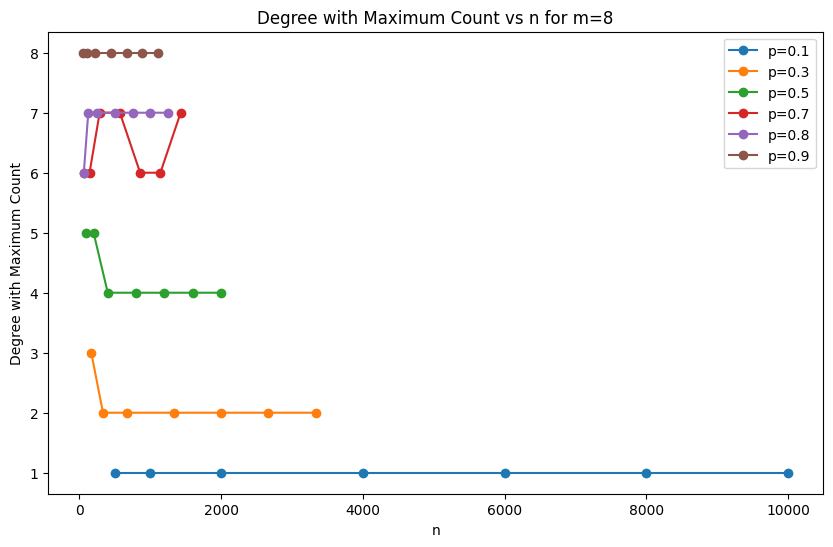

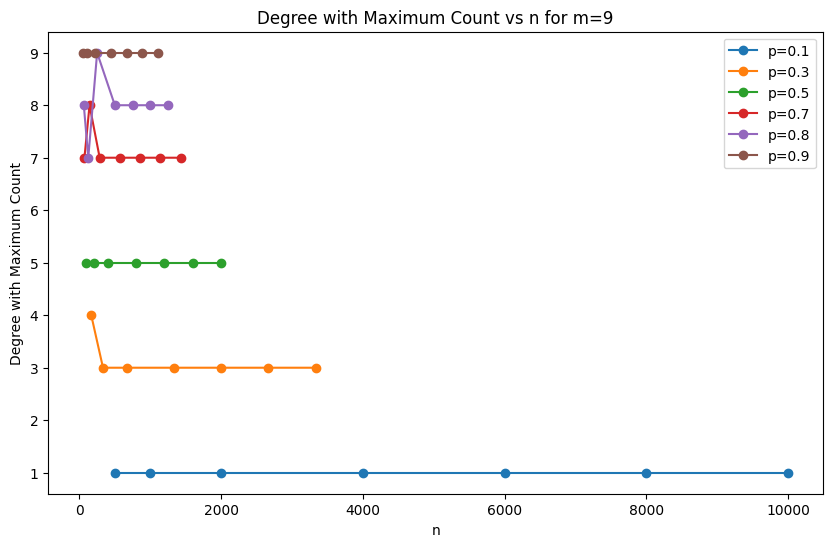

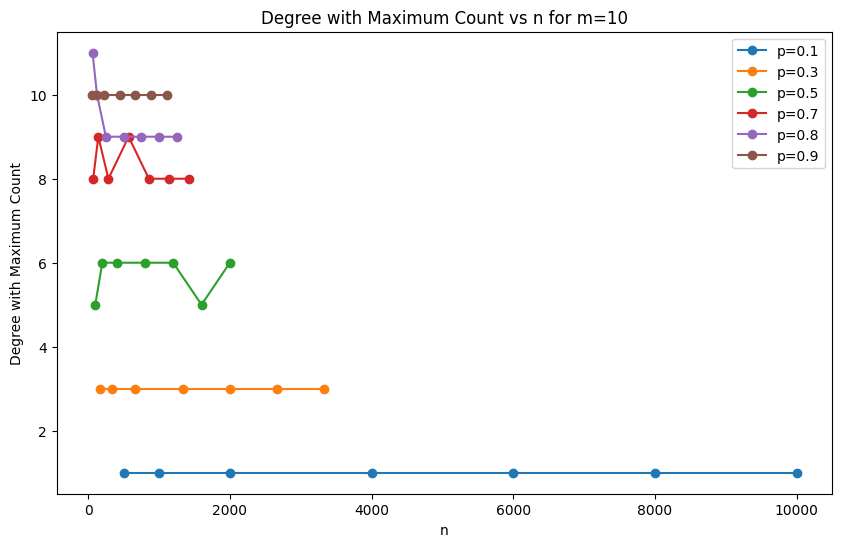

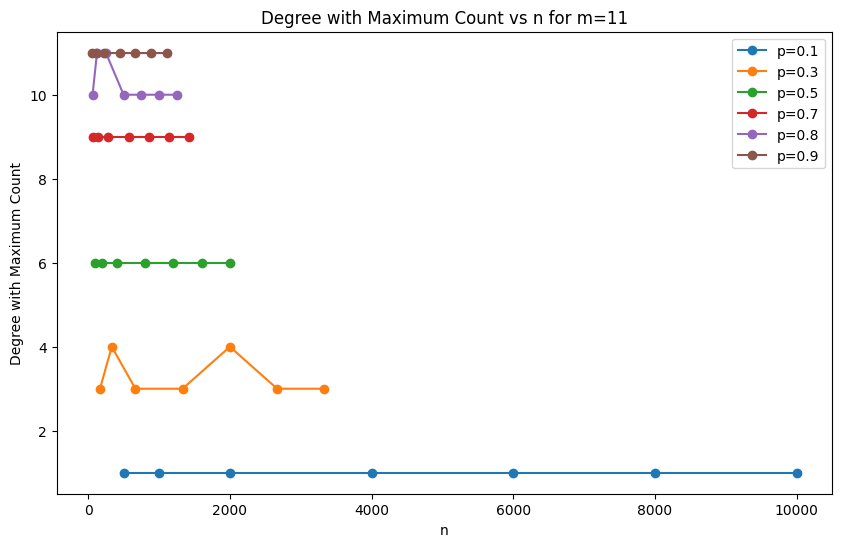

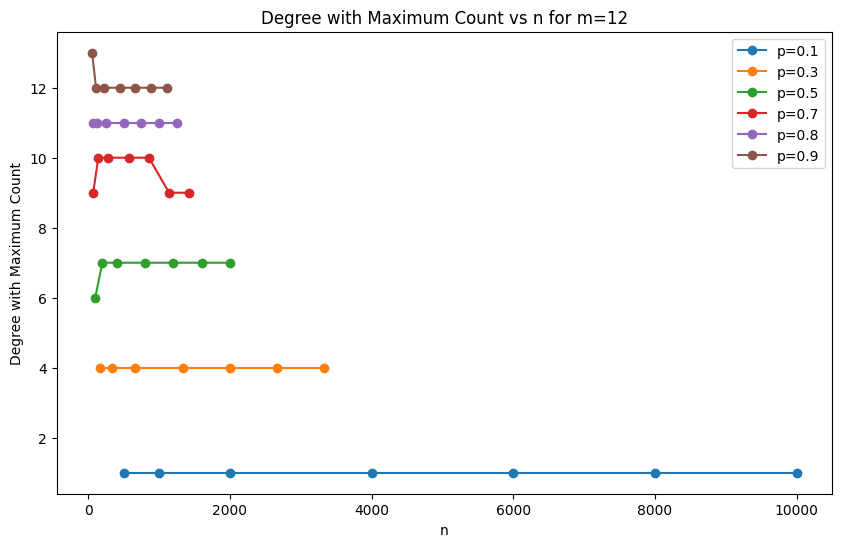

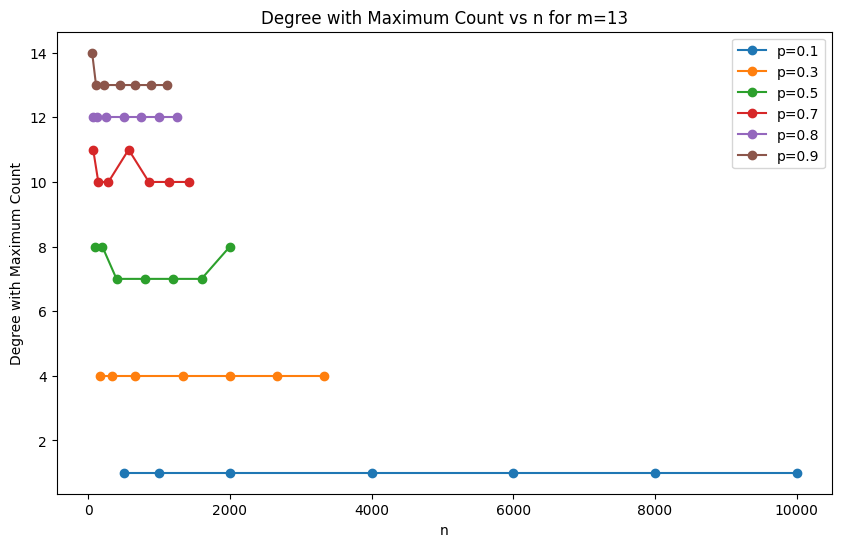

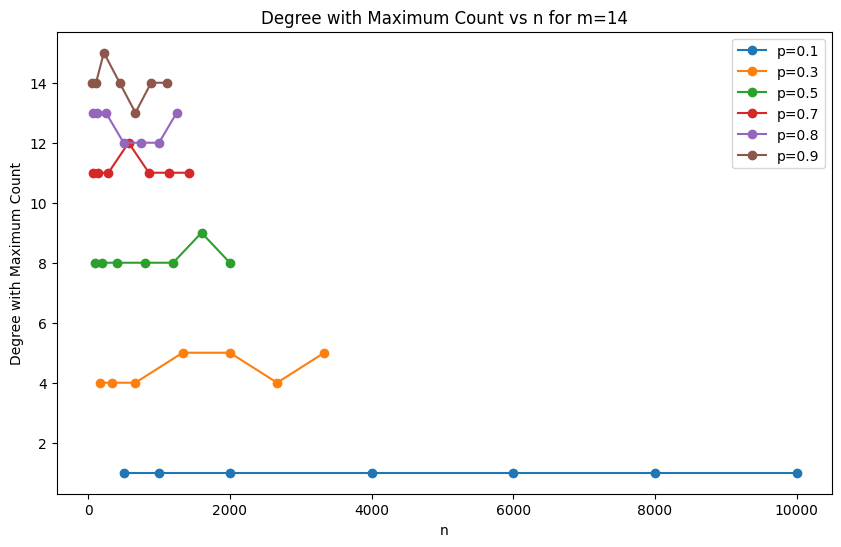

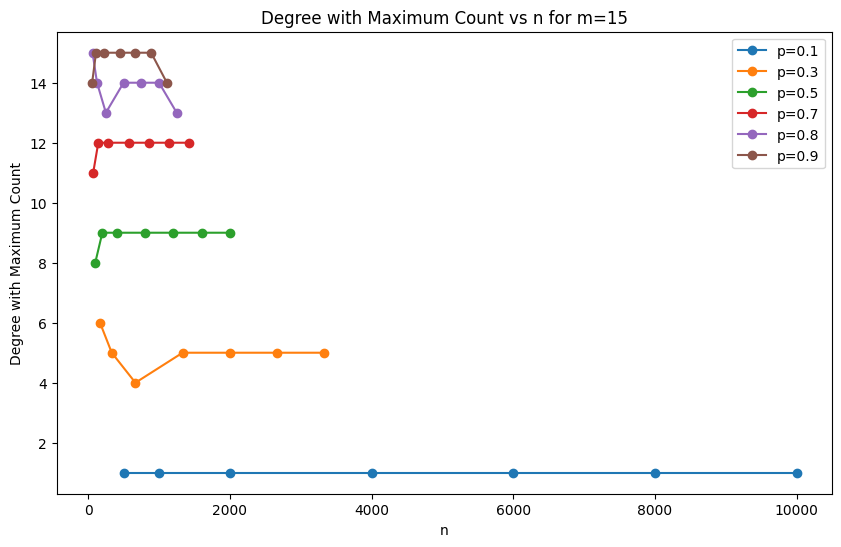

In [16]:
for m in M_VALUES:
    plt.figure(figsize=(10, 6))
    for p in P_VALUES:
        x = []
        y = []
        for n in N_VALUES:
            n_div_p = round(n / p)
            key = (n_div_p, m, p)
            if key in max_count_deg:
                max_deg, max_count = max_count_deg[key]
                x.append(n_div_p)
                y.append(max_deg)

        plt.plot(x, y, marker='o', label=f'p={p}')
        
    plt.title(f'Degree with Maximum Count vs n for m={m}')
    plt.xlabel('n')
    plt.ylabel('Degree with Maximum Count')
    plt.legend()
    plt.show()

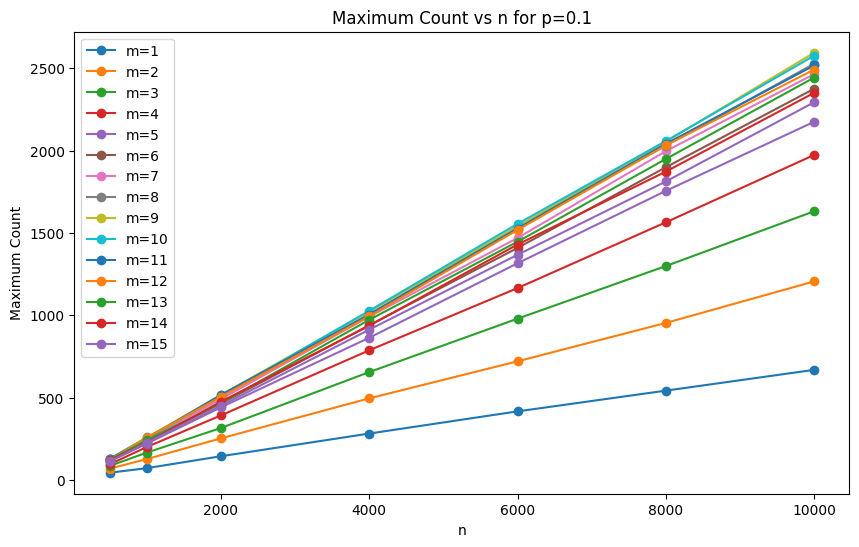

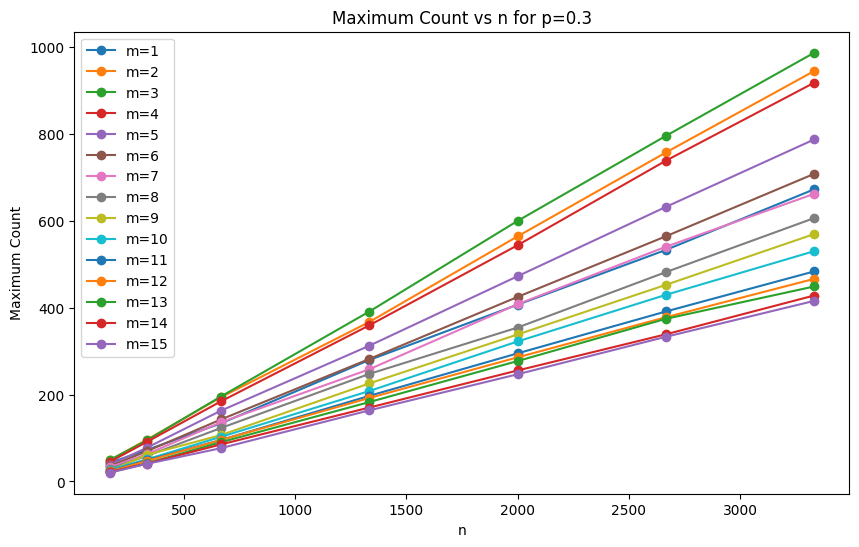

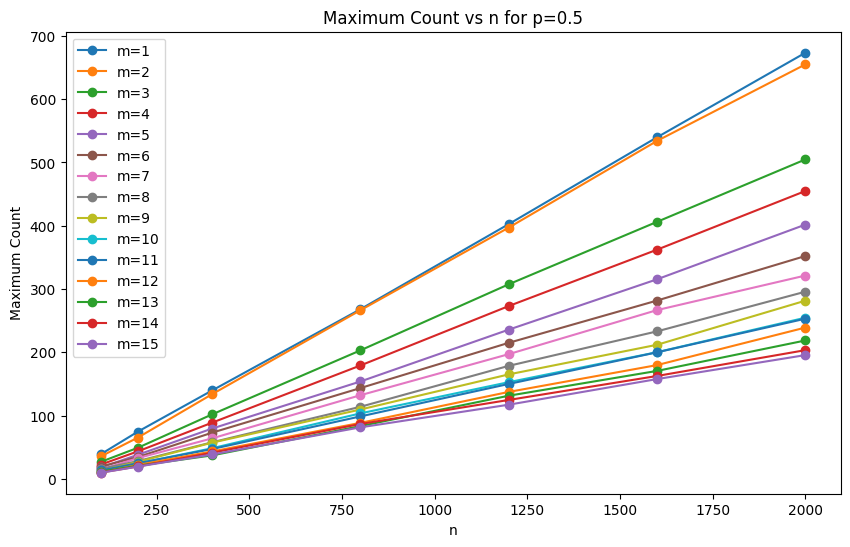

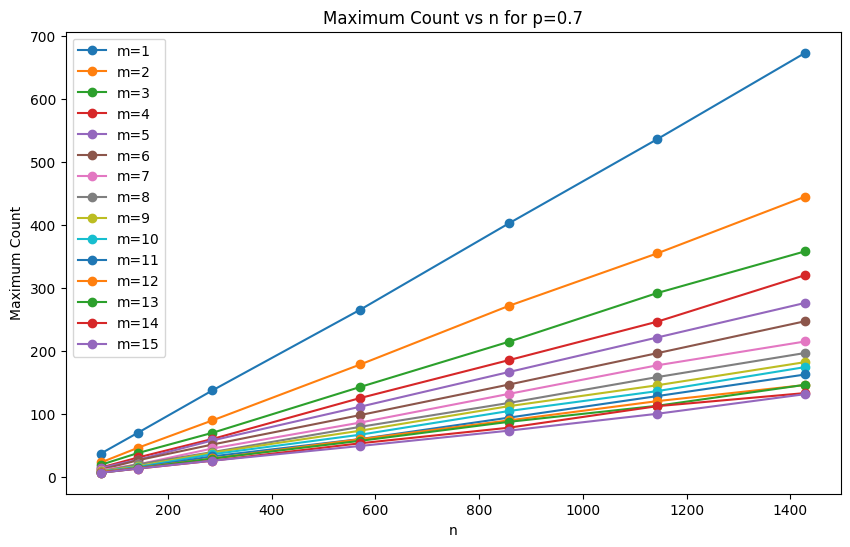

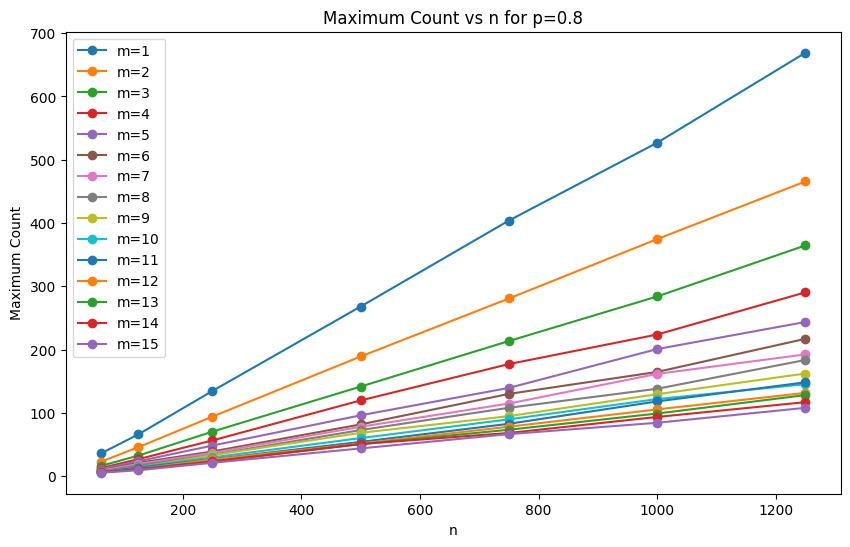

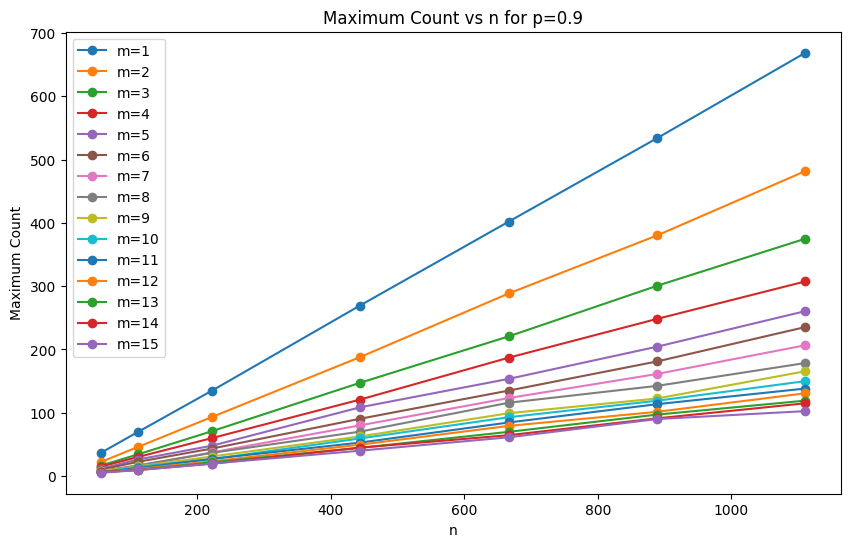

In [17]:
for p in P_VALUES:
    plt.figure(figsize=(10, 6))
    for m in M_VALUES:
        x = []
        y = []
        for n in N_VALUES:
            n_div_p = round(n / p)
            key = (n_div_p, m, p)
            if key in max_count_deg:
                max_deg, max_count = max_count_deg[key]
                x.append(n_div_p)
                y.append(max_count)

        plt.plot(x, y, marker='o', label=f'm={m}')
    
    plt.title(f'Maximum Count vs n for p={p}')
    plt.xlabel('n')
    plt.ylabel('Maximum Count')
    plt.legend()
    plt.show()

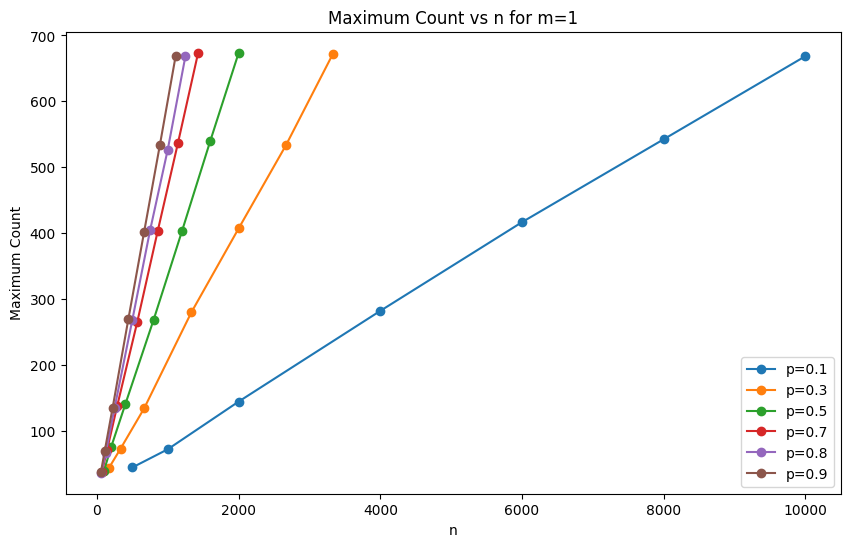

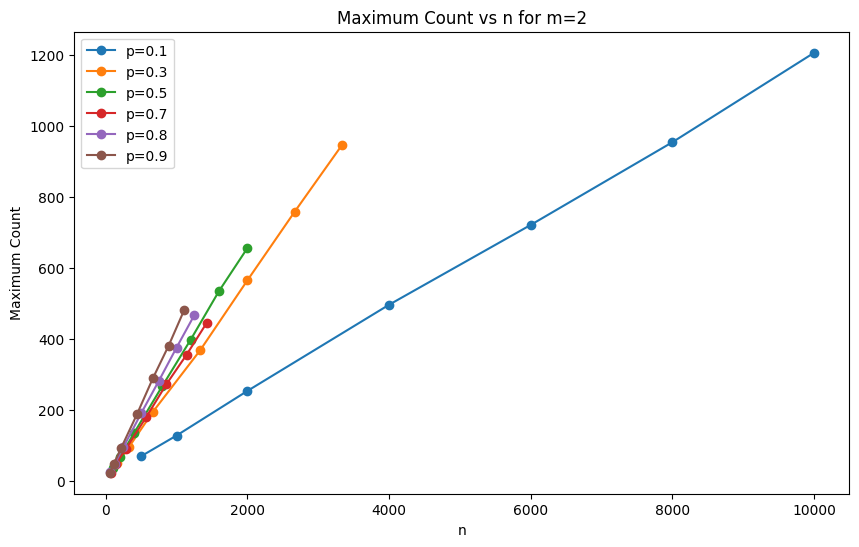

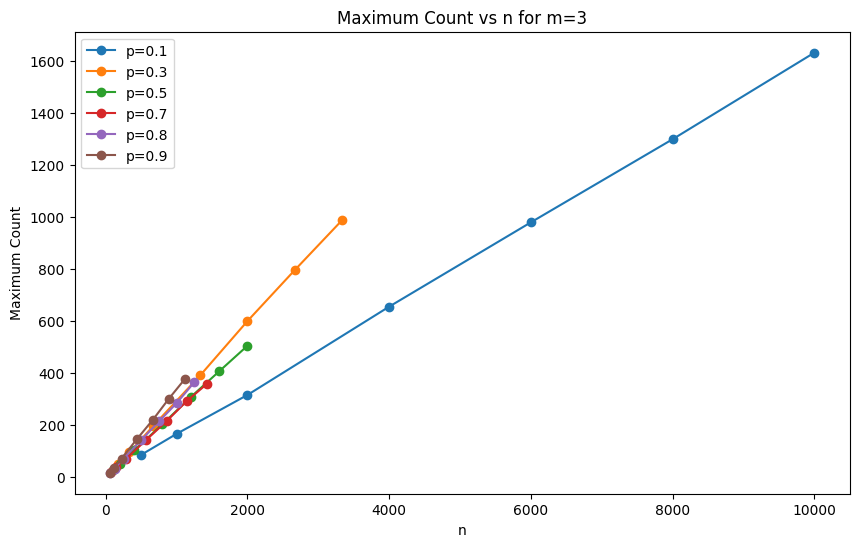

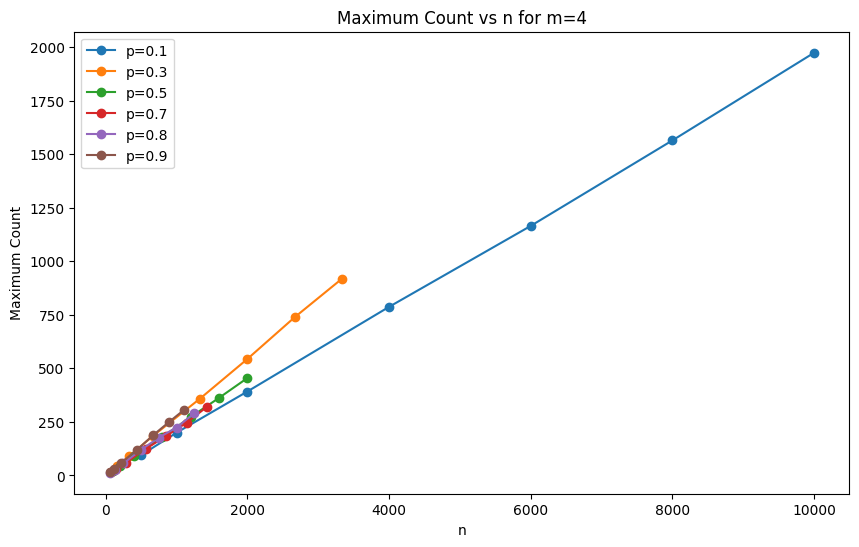

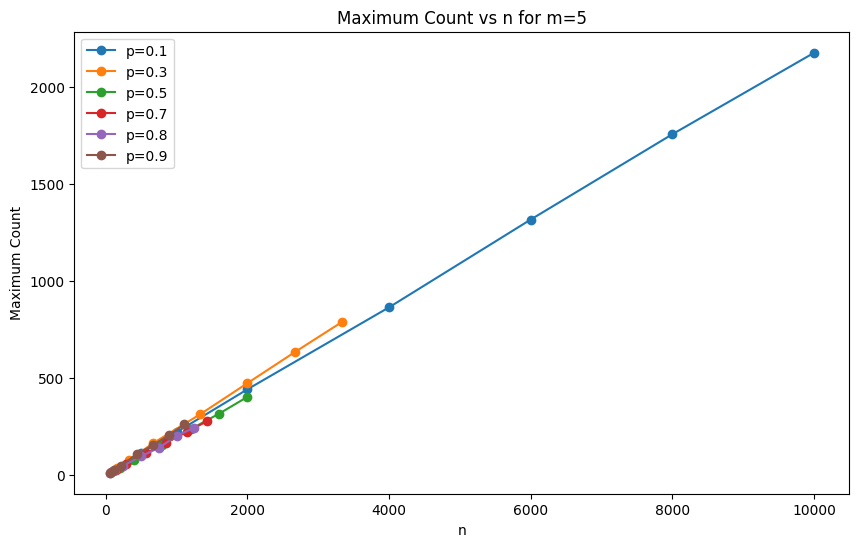

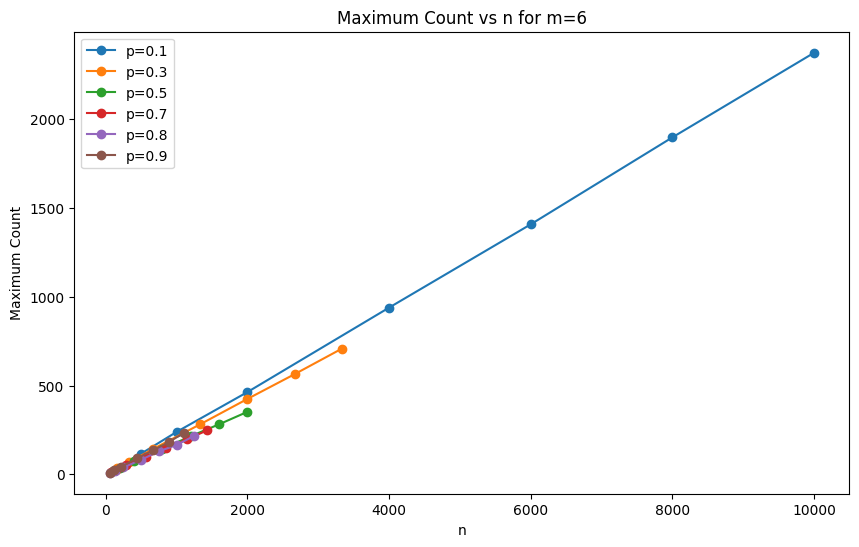

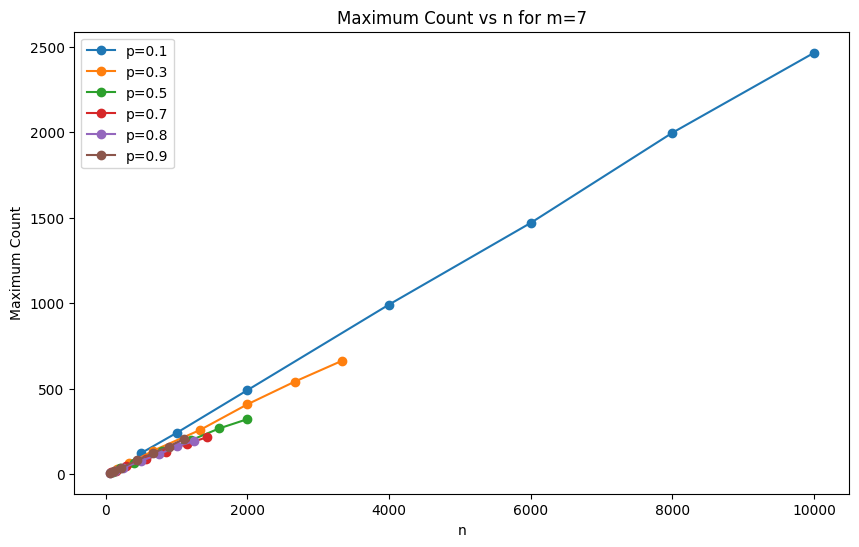

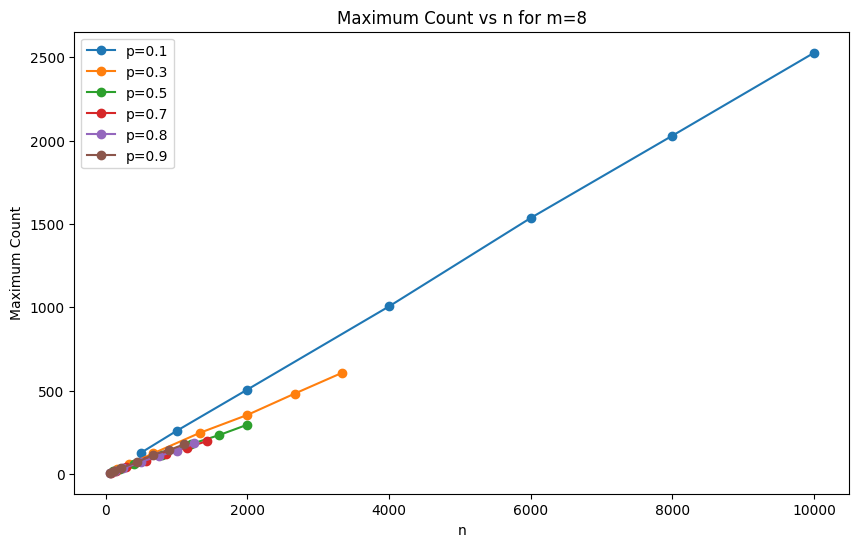

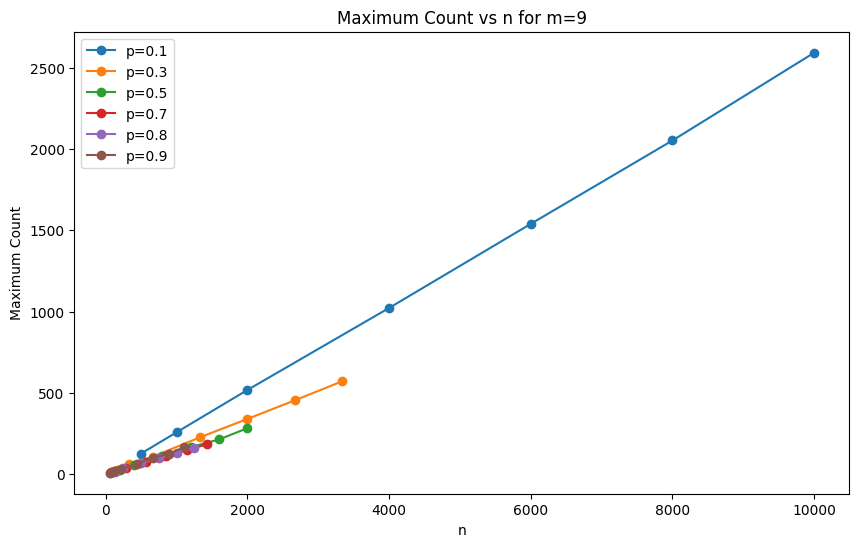

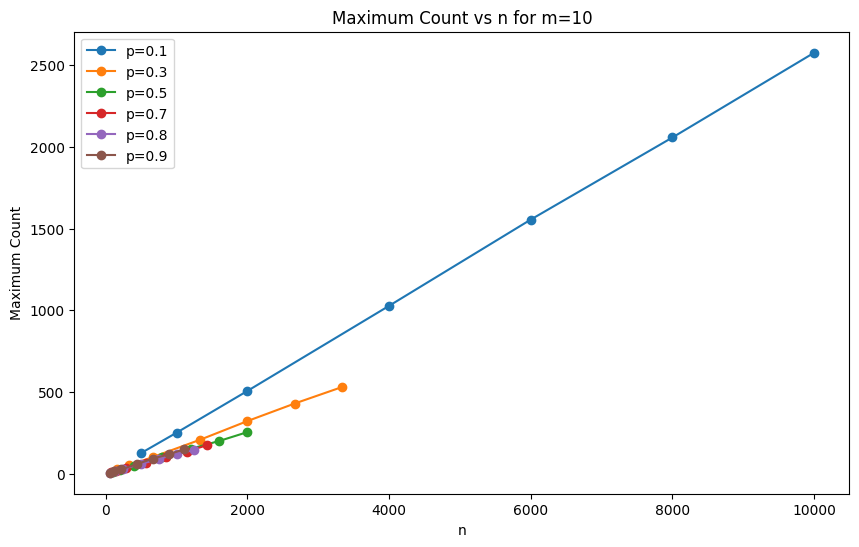

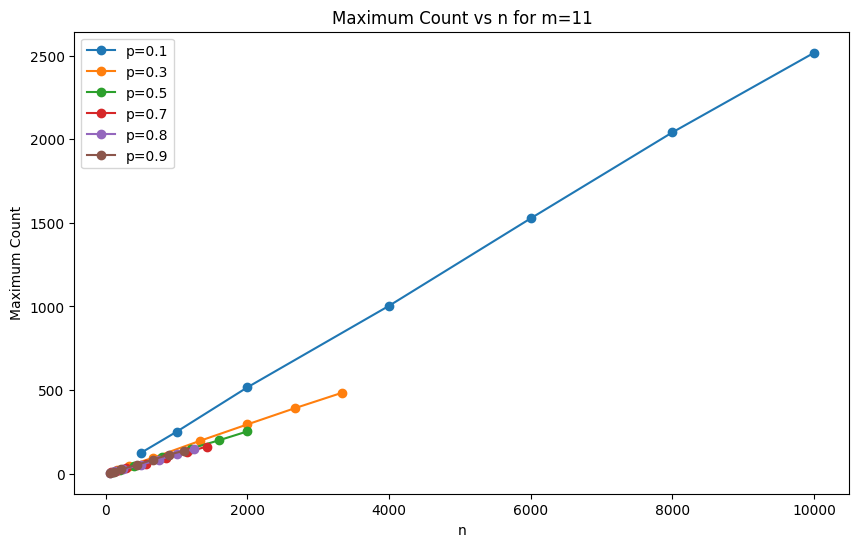

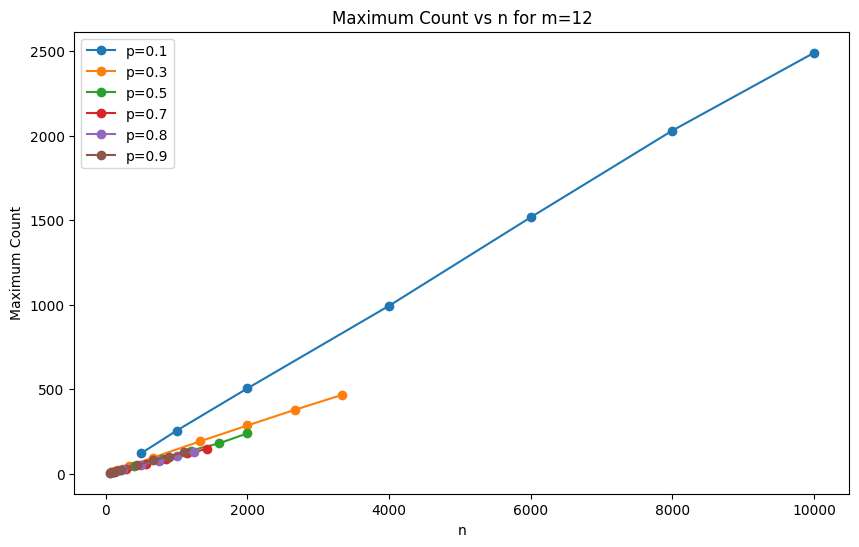

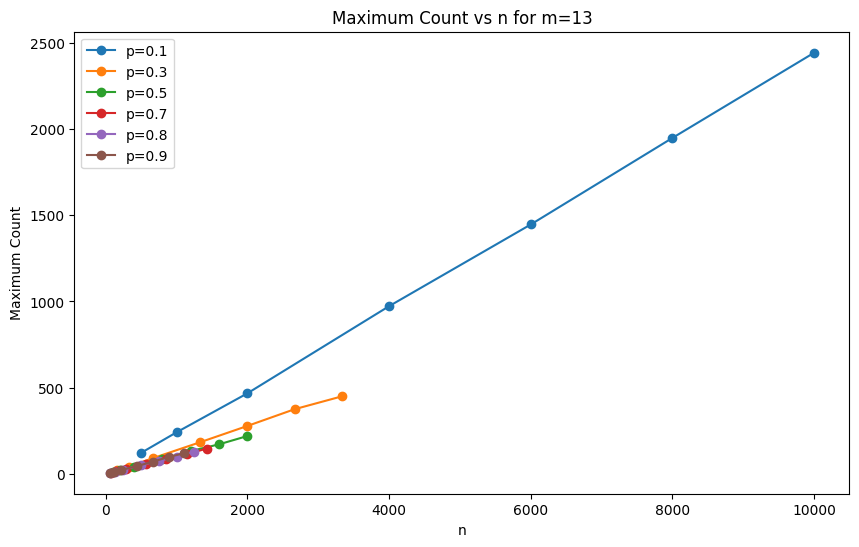

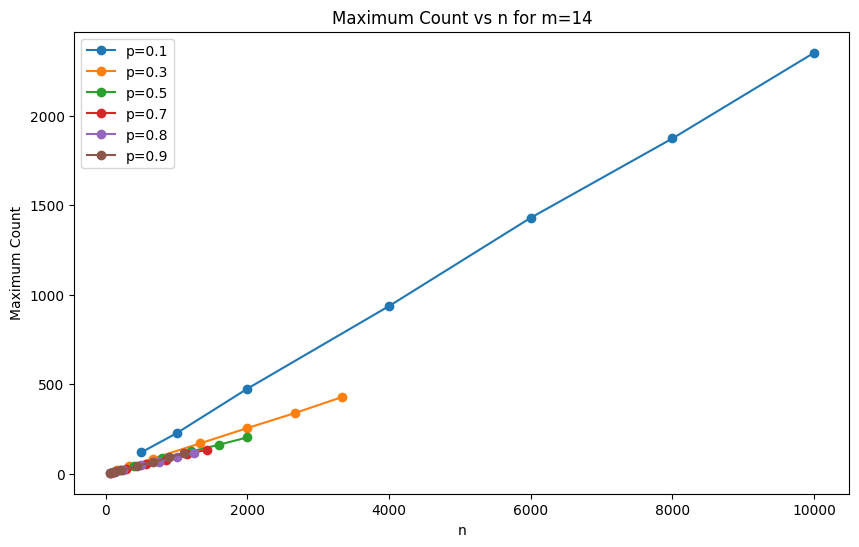

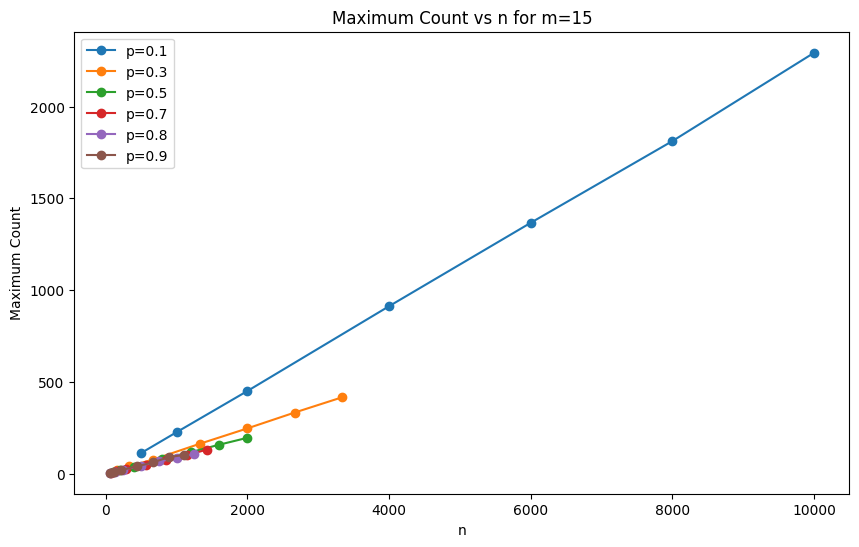

In [18]:
for m in M_VALUES:
    plt.figure(figsize=(10, 6))
    for p in P_VALUES:
        x = []
        y = []
        for n in N_VALUES:
            n_div_p = round(n / p)
            key = (n_div_p, m, p)
            if key in max_count_deg:
                max_deg, max_count = max_count_deg[key]
                x.append(n_div_p)
                y.append(max_count)

        plt.plot(x, y, marker='o', label=f'p={p}')

    plt.title(f'Maximum Count vs n for m={m}')
    plt.xlabel('n')
    plt.ylabel('Maximum Count')
    plt.legend()
    plt.show()

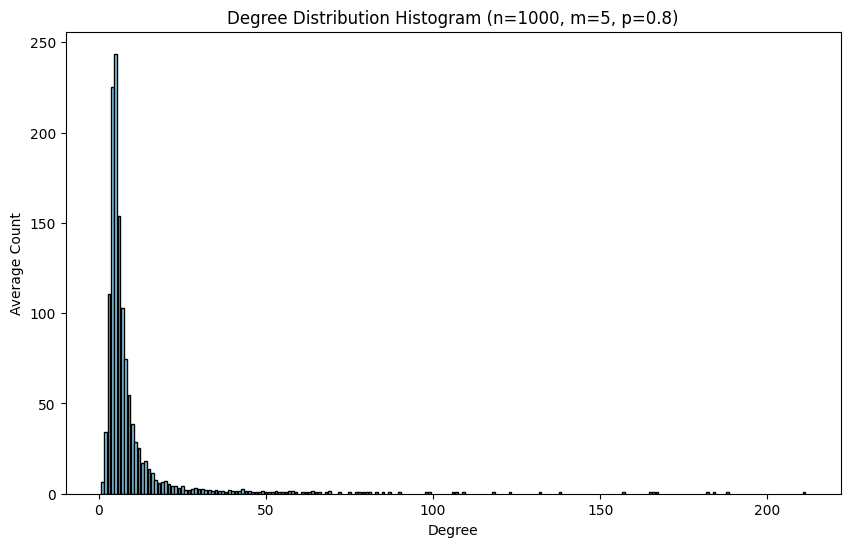

In [19]:
N = 1000
M = 5
P = 0.8

plt.figure(figsize=(10, 6))
key = (round(N / P), M, P)
degs = list(results[key].keys())
counts = list(results[key].values())
plt.bar(degs, counts, width=0.8, color="skyblue", edgecolor="black")
plt.xlabel('Degree')
plt.ylabel('Average Count')
plt.title(f'Degree Distribution Histogram (n={N}, m={M}, p={P})')
plt.show()

In [20]:
import math


def compute_degree_distribution(m, p, k_max=50):
    """
    Compute stationary degree distribution P_k for generalized BA model
    where each of m candidate edges is created with probability p.

    Parameters:
        m (int): number of candidate edges per new node
        p (float): probability of keeping each edge
        k_max (int): maximum degree to compute

    Returns:
        list of floats: P[k] for k=0,...,k_max
    """
    # insertion distribution b_r (Binomial)
    b = [math.comb(m, r) * (p**r) * ((1-p)**(m-r)) for r in range(m+1)]

    # extend with zeros so indexing is safe up to k_max
    b += [0.0] * (k_max - m)

    # storage for P_k
    P = [0.0] * (k_max+1)

    # recurrence
    for k in range(k_max+1):
        if k == 0:
            P[0] = b[0]
        else:
            P[k] = ((k-1) * P[k-1] + 2 * b[k]) / (k + 2)

    # normalize (should already be close to 1)
    total = sum(P)
    P = [pk/total for pk in P]
    return P


m = 3
p = 0.4
k_max = 50
P = compute_degree_distribution(m, p, k_max)

print(f"Degree distribution for m={m}, p={p}")
for k, pk in enumerate(P):
    print(f"P[{k}] = {pk:.6f}")


Degree distribution for m=3, p=0.4
P[0] = 0.216274
P[1] = 0.288365
P[2] = 0.216274
P[3] = 0.112142
P[4] = 0.056071
P[5] = 0.032041
P[6] = 0.020025
P[7] = 0.013350
P[8] = 0.009345
P[9] = 0.006796
P[10] = 0.005097
P[11] = 0.003921
P[12] = 0.003081
P[13] = 0.002465
P[14] = 0.002003
P[15] = 0.001649
P[16] = 0.001374
P[17] = 0.001157
P[18] = 0.000984
P[19] = 0.000843
P[20] = 0.000728
P[21] = 0.000633
P[22] = 0.000554
P[23] = 0.000488
P[24] = 0.000431
P[25] = 0.000383
P[26] = 0.000342
P[27] = 0.000307
P[28] = 0.000276
P[29] = 0.000249
P[30] = 0.000226
P[31] = 0.000206
P[32] = 0.000187
P[33] = 0.000171
P[34] = 0.000157
P[35] = 0.000144
P[36] = 0.000133
P[37] = 0.000123
P[38] = 0.000114
P[39] = 0.000105
P[40] = 0.000098
P[41] = 0.000091
P[42] = 0.000085
P[43] = 0.000079
P[44] = 0.000074
P[45] = 0.000069
P[46] = 0.000065
P[47] = 0.000061
P[48] = 0.000057
P[49] = 0.000054
P[50] = 0.000051


In [21]:
N0 = 15
M = 12
N = 1000
P = 0.7

G = generate_graph(N0, N, M, lambda k: k, lambda k: P)

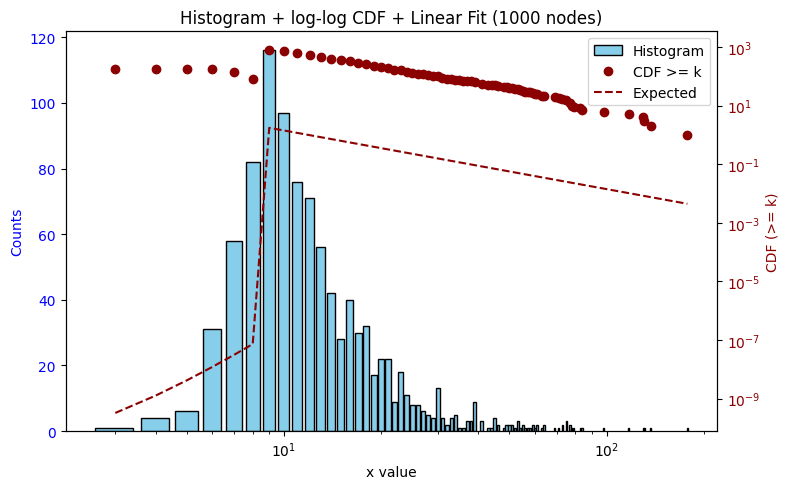

In [26]:
def compute_pk(m, p, k_max=50):
    """
    Compute stationary degree distribution P_k for generalized BA model
    where each of m candidate edges is created with probability p.


    Parameters:
    m (int): number of candidate edges per new node
    p (float): probability of keeping each edge
    k_max (int): maximum degree to compute


    Returns:
    list of floats: P[k] for k=0,...,k_max
    """
    # insertion distribution b_r (Binomial)
    b = [math.comb(m, r) * (p**r) * ((1-p)**(m-r)) for r in range(m+1)]

    # extend with zeros so indexing is safe up to k_max
    b += [0.0] * (k_max - m)

    P = []
    for k in range(k_max+1):
        if k < 2:
            # Handle k=0,1 separately to avoid division by zero
            if k == 0:
                P.append(b[0])
            else:
                val = (2.0 / (1*2*3)) * sum(math.comb(2, r) * b[r] for r in range(min(2, m)+1))
                P.append(val)
        else:
            s = sum(math.comb(k+1, r) * b[r] for r in range(min(k, m)+1))
            val = (2.0 / (k * (k+1) * (k+2))) * s
            P.append(val)

    # normalize (should already be close to 1)
    total = sum(P)
    P = [pk/total for pk in P]
    return P


Pk = compute_pk(M, P, k_max=50)

def analyse_graph3(G: nx.Graph) -> None:
    degs_list = sorted([degree for _, degree in G.degree])
    degs = sorted(list(set(degs_list)))
    counts = [degs_list.count(deg) for deg in degs]

    max_count_index = counts.index(max(counts))

    increasing_counts = counts[: max_count_index]
    decreasing_counts = counts[max_count_index:]

    cdf1 = np.cumsum(increasing_counts[::-1])[::-1]
    cdf2 = np.cumsum(decreasing_counts[::-1])[::-1]
    log_deg = np.log(degs)
    log_cdf1 = np.log(cdf1)
    log_cdf2 = np.log(cdf2)

    expected = [Pk[deg] for deg in degs[: max_count_index]] + [2 * (M*P)**2 * deg**(-2.0) for deg in degs[max_count_index:]]
    # expected = [1 / math.log(deg) * math.exp(-deg / math.log(deg)) for deg in degs]

    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.bar(
        degs, counts, width=0.8, color="skyblue", edgecolor="black", label="Histogram"
    )
    ax1.set_xlabel("x value")
    ax1.set_ylabel("Counts", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")
    ax1.set_title(f"Histogram + log-log CDF + Linear Fit ({sum(counts)} nodes)")

    ax2 = ax1.twinx()
    ax2.plot(degs[:max_count_index], np.exp(log_cdf1), "o", color="darkred")
    ax2.plot(degs[max_count_index:], np.exp(log_cdf2), "o", color="darkred", label="CDF >= k")
    ax2.plot(degs, expected, "--", color="darkred", label="Expected")
    ax2.set_ylabel("CDF (>= k)", color="darkred")
    ax2.set_yscale("log")
    ax2.set_xscale("log")
    ax2.tick_params(axis="y", labelcolor="darkred")

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

    plt.tight_layout()
    plt.show()

analyse_graph3(G)